# پروژه مدل‌سازی صندوق بازنشستگی (Fully funded DC)
 
# نام استاد: دکتر امیرتیمور پاینده
# نام دانشجو: محمد اشکوری
# شماره دانشجویی : 404422013

## مرحله ۱: آماده‌سازی و اعتبارسنجی داده‌ها

---
# مرحله 1: آماده‌سازی و اعتبارسنجی داده‌ها (Data Preparation & Validation)
در این مرحله داده‌های صندوق بازنشستگی از فایل اکسل فراخوانی شده و اعتبارسنجی‌های زیر روی آن‌ها صورت می‌گیرد:
- **کنترل یکپارچگی جمعیت:** بررسی تعداد کل اعضا و توزیع آن‌ها در وضعیت‌های شاغل (Active)، بازنشسته (Retired) و بازمانده (Survivor).
- **کنترل مقادیر گمشده (Missing Values):** شناسایی ستون‌هایی که فاقد اطلاعات کامل هستند.
- **اعتبارسنجی منطقی (Logical Checks):** اطمینان از اینکه اعضای فعال دارای حقوق سالانه و اعضای غیرفعال دارای مستمری تخصیص‌یافته هستند.
- **آمار توصیفی:** استخراج میانگین و کران‌های سن، سابقه و موجودی حساب انفرادی (DC Account Balance).


In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedMarkdown,
.jp-RenderedHTMLCommon {
    direction: rtl !important;
    text-align: right !important;
    unicode-bidi: plaintext;
}

.jp-RenderedMarkdown p,
.jp-RenderedMarkdown h1,
.jp-RenderedMarkdown h2,
.jp-RenderedMarkdown h3,
.jp-RenderedMarkdown ul,
.jp-RenderedMarkdown ol,
.jp-RenderedMarkdown li {
    direction: rtl !important;
    text-align: right !important;
}

.jp-RenderedMarkdown code,
.jp-RenderedMarkdown pre {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed;
}
</style>
"""))

In [2]:
%pip install openpyxl

import pandas as pd
import numpy as np

# تنظیمات نمایشی
pd.set_option('display.float_format', lambda x: '%.0f' % x)
pd.set_option('display.max_columns', None)

file_path = 'Actuarial_Fund_Data_500_DC_Fuller.xlsx'

try:
    # 1. خواندن فایل اکسل با تعیین دقیق انجین
    df_members = pd.read_excel(file_path, sheet_name='Members', engine='openpyxl')
    df_assumptions = pd.read_excel(file_path, sheet_name='Assumptions', engine='openpyxl')
    print("✅ داده‌ها با موفقیت فراخوانی شدند.\n")
    
    # 2. کنترل تعداد اعضا و وضعیت‌ها
    total_members = len(df_members)
    status_counts = df_members['Status'].value_counts().to_dict()

    # 3. کنترل کیفیت مقادیر گمشده
    missing_data = df_members.isnull().sum()
    missing_data = missing_data[missing_data > 0].to_dict()

    # 4. اعتبارسنجی منطقی (حقوق شاغلین و مستمری غیرشاغلین)
    active_salary = df_members.loc[df_members['Status'] == 'Active', 'Current_Annual_Salary'].sum()
    retiree_pension = df_members.loc[df_members['Status'] == 'Retired', 'Pension_Annual'].sum()
    survivor_pension = df_members.loc[df_members['Status'] == 'Survivor', 'Pension_Annual'].sum()

    # 5. آمار توصیفی ستون‌های کلیدی اکچوئری
    key_cols = ['Current_Age', 'Entry_Age', 'Service_Years', 'Current_Annual_Salary', 'Current_Account_Balance']
    stats_df = df_members[key_cols].describe().T[['count', 'mean', 'min', 'max']]

    # --- چاپ گزارش خروجی جهت تفسیر اکچوئری ---
    print("="*50)
    print("گزارش اعتبارسنجی داده‌های صندوق (Data Validation Report)")
    print("="*50)
    print(f"Total Members Count: {total_members}")
    print(f"Members by Status:   {status_counts}")
    print("-" * 50)
    print(f"Missing Values: {missing_data if missing_data else 'None'}")
    print("-" * 50)
    print(f"Total Active Payroll (Annual):   {active_salary:,.0f} IRR")
    print(f"Total Retiree Pension (Annual):  {retiree_pension:,.0f} IRR")
    print(f"Total Survivor Pension (Annual): {survivor_pension:,.0f} IRR")
    print("-" * 50)
    print("Key Actuarial Statistics:")
    print(stats_df)
    print("="*50)

except Exception as e:
    print(f"❌ خطا: {e}")
    print("لطفاً مطمئن شوید فایل اکسل دقیقاً در همان پوشه جاری نوت‌بوک آپلود شده است.")


✅ داده‌ها با موفقیت فراخوانی شدند.

گزارش اعتبارسنجی داده‌های صندوق (Data Validation Report)
Total Members Count: 500
Members by Status:   {'Active': 402, 'Retired': 73, 'Survivor': 25}
--------------------------------------------------
Missing Values: {'Date_of_Employment': 25, 'Survivor_Category': 475}
--------------------------------------------------
Total Active Payroll (Annual):   2,834,867,400,000 IRR
Total Retiree Pension (Annual):  75,119,400,000 IRR
Total Survivor Pension (Annual): 17,150,900,000 IRR
--------------------------------------------------
Key Actuarial Statistics:
                         count        mean       min          max
Current_Age                500          47        25           88
Entry_Age                  500          25        20           30
Service_Years              500          23         1           66
Current_Annual_Salary      500  5669734800         0  16241100000
Current_Account_Balance    500 59668300400 171100000 329000000000


---
###  گزلرش مرحله ۱: اعتبارسنجی داده‌ها  (Data Validation Report)

**۱. وضعیت جمعیتی:**
صندوق از **۵۰۰ عضو** تشکیل شده است که ترکیب آن کاملاً منطقی است: 
- ۴۰۲ نفر فعال (مشارکت‌کننده)
- ۷۳ نفر بازنشسته (مستمری‌بگیر)
- ۲۵ پرونده بازماندگان

میانگین سنی ۴۷ سال نشان‌دهنده یک صندوق نسبتاً بالغ (Mature) است که به تدریج با موج بازنشستگی مواجه خواهد شد.

**۲. یکپارچگی داده‌ها (Data Integrity):**
- **مقادیر گمشده:** ۲۵ رکورد فاقد `Date_of_Employment` دقیقاً برابر با تعداد بازماندگان (Survivor) است که از نظر اکچوئری صحیح است (زیرا بازماندگان مستخدم نیستند). همچنین ۴۷۵ رکورد فاقد `Survivor_Category` هستند که معادل مجموع شاغلین و بازنشستگان (۴۰۲ + ۷۳) است. بنابراین، هیچ دیتای ناقص بحرانی در متغیرهای کلیدی نداریم.
- **دامنه متغیرها:** سن فعلی بین ۲۵ تا ۸۸ سال و سن ورود بین ۲۰ تا ۳۰ سال است که با قوانین استخدامی رایج همخوانی کامل دارد.

**۳. نمای مالی فعلی:**
- مجموع حقوق مشمول کسر حق‌بیمه اعضای فعال حدود **۲,۸۳۴ میلیارد ریال** در سال است که پایه اصلی تولید جریان نقدی (Cashflow) ورودی صندوق در مدل ما خواهد بود.
- تعهدات خروجی فعلی معادل حدود **۹۲٫۲ میلیارد ریال** در سال (۷۵ میلیارد برای بازنشستگان و ۱۷ میلیارد برای بازماندگان) است.
- موجودی حساب‌های DC اعضا به طور متوسط حدود **۵۹٫۶ میلیارد ریال** است که پایه محاسبات مستمری زمان بازنشستگی را تشکیل می‌دهد.


---
##  مرحله 2: تعریف مفروضات و توابع پایه اکچوئری (Actuarial Assumptions & Functions)

In [3]:
import pandas as pd

try:
    # فراخوانی شیت‌های مورد نیاز (با فرض اینکه file_path از مرحله قبل موجود است)
    file_path = 'Actuarial_Fund_Data_500_DC_Fuller.xlsx'
    df_assumptions = pd.read_excel(file_path, sheet_name='Assumptions', engine='openpyxl')
    df_mortality = pd.read_excel(file_path, sheet_name='Mortality', engine='openpyxl')
    
    # 1. استخراج مفروضات اقتصادی به شکل دیکشنری
    assumptions = dict(zip(df_assumptions['Parameter'], df_assumptions['Value']))
    
    discount_rate = float(assumptions.get('Discount_Rate', 0.16)) # i = 16%
    salary_growth = float(assumptions.get('Salary_Growth_Rate', 0.15))
    inv_return = float(assumptions.get('Investment_Return', 0.18))
    
    # 2. آماده‌سازی بردارهای مرگ‌ومیر (lx) برای دسترسی سریع (O(1))
    lx_male = dict(zip(df_mortality['Age'], df_mortality['lx_male']))
    lx_female = dict(zip(df_mortality['Age'], df_mortality['lx_female']))
    
    # 3. تعریف تابع احتمال بقا (tpx)
    def calc_tpx(x, t, sex='M'):
        lx_dict = lx_male if sex == 'M' else lx_female
        if x + t > 120 or x not in lx_dict or lx_dict[x] == 0:
            return 0.0
        return lx_dict[x + t] / lx_dict[x]

    # 4. تعریف تابع ارزش فعلی مستمری (Immediate Annuity)
    def calc_ax_immediate(x, sex='M', interest_rate=discount_rate):
        ax = 0.0
        v = 1 / (1 + interest_rate)
        lx_dict = lx_male if sex == 'M' else lx_female
        
        if x not in lx_dict or lx_dict[x] == 0:
            return 0.0
            
        for t in range(1, 120 - x + 1):
            if x + t > 120:
                break
            tpx = calc_tpx(x, t, sex)
            ax += (v ** t) * tpx
        return ax

    # 5. محاسبه ارزش فعلی مستمری در سن بازنشستگی (60 سالگی) به عنوان تست
    ax_60_m = calc_ax_immediate(60, 'M', discount_rate)
    ax_60_f = calc_ax_immediate(60, 'F', discount_rate)
    
    print("✅ مفروضات و توابع اکچوئری با موفقیت بارگذاری شدند.\n")
    print("-" * 50)
    print(f"Discount Rate (i):        {discount_rate*100:.2f}%")
    print(f"Investment Return:        {inv_return*100:.2f}%")
    print(f"Salary Growth Rate:       {salary_growth*100:.2f}%")
    print("-" * 50)
    print(f"10-Year Survival Prob (10p60) Male:   {calc_tpx(60, 10, 'M'):.4f}")
    print(f"10-Year Survival Prob (10p60) Female: {calc_tpx(60, 10, 'F'):.4f}")
    print("-" * 50)
    print(f"Annuity Factor a_60 (Male):   {ax_60_m:.4f}")
    print(f"Annuity Factor a_60 (Female): {ax_60_f:.4f}")
    print("=" * 50)
    
except Exception as e:
    print(f"❌ خطا در اجرای توابع: {e}")


✅ مفروضات و توابع اکچوئری با موفقیت بارگذاری شدند.

--------------------------------------------------
Discount Rate (i):        16.00%
Investment Return:        18.00%
Salary Growth Rate:       15.00%
--------------------------------------------------
10-Year Survival Prob (10p60) Male:   0.8206
10-Year Survival Prob (10p60) Female: 0.8445
--------------------------------------------------
Annuity Factor a_60 (Male):   5.3905
Annuity Factor a_60 (Female): 5.4926


---
###   گزارش مرحله ۲: مفروضات کلان و فاکتورهای تبدیل مستمری (Annuity Factors)

در این فاز، مفروضات اقتصادی و بیومتریک صندوق پیاده‌سازی شده و توابع پایه اکچوئری جهت محاسبه ارزش فعلی مستمری‌ها توسعه یافتند.

**۱. مفروضات اقتصادی (Economic Assumptions):**
- نرخ تنزیل (Discount Rate): $i = 16\%$
- نرخ بازده سرمایه‌گذاری (Investment Return): $j = 18\%$
- نرخ رشد حقوق (Salary Growth Rate): $g = 15\%$
این مفروضات نشان‌دهنده یک محیط تورمی با حاشیه سود واقعی مثبت برای سرمایه‌گذاری‌ها ($j > g$ و $j > i$) است که برای پایداری صندوق‌های DC حیاتی است.

**۲. تحلیل احتمالات بقا (Survival Probabilities):**
بررسی احتمال بقای ۱۰ ساله برای افراد ۶۰ ساله ($_{10}p_{60}$):
- **مردان:** $0.8206$ (حدود ۸۲٪ احتمال بقا تا ۷۰ سالگی)
- **زنان:** $0.8445$ (حدود ۸۴.۵٪ احتمال بقا تا ۷۰ سالگی)
این خروجی با اصول پایه اکچوئری و جداول استاندارد مرگ‌ومیر مطابقت کامل دارد، زیرا امید به زندگی زنان به طور ساختاری بالاتر از مردان است.

**۳. فاکتورهای تبدیل مستمری (Annuity Factors - $a_{60}$):**
ارزش فعلی مستمری مادام‌العمر به مبلغ یک ریال در سال که از سن ۶۰ سالگی آغاز می‌شود ($a_{60}$)، به شرح زیر محاسبه گردید:
- **مردان:** $a_{60}^{(Male)} = 5.3905$
- **زنان:** $a_{60}^{(Female)} = 5.4926$

**نتیجه‌گیری فاز ۲:**
بالاتر بودن فاکتور $a_{60}$ برای زنان به دلیل احتمال بقای بیشتر آن‌هاست. در مدل **DC (Defined Contribution)**، این فاکتورها به عنوان «مخرج کسر» برای تبدیل موجودی نهایی حساب (Projected Fund) به مستمری سالانه (Annual Pension) عمل خواهند کرد. به عبارت دیگر، با یک موجودی حساب یکسان در سن ۶۰ سالگی، زنان به دلیل طول عمر بیشتر (و در نتیجه مخرج کسر بزرگتر)، مستمری سالانه کمتری نسبت به مردان دریافت خواهند کرد که ذات عادلانه (Actuarial Fairness) سیستم‌های DC خالص را نشان می‌دهد.


---
## مرحله3:مدل‌سازی اعضای فعال و پروجکشن موجودی بازنشستگی

In [4]:
import pandas as pd
import numpy as np

# ۱. بارگذاری داده‌ها و پاک‌سازی نام ستون‌ها
df_members = pd.read_excel('Actuarial_Fund_Data_500_DC_Fuller.xlsx', sheet_name='Members')
df_members.columns = df_members.columns.str.strip()

# ۲. فراخوانی مفروضات (از فاز ۲)
inv_return = 0.18  # نرخ بازده سرمایه‌گذاری (۱۸٪)
sal_growth = 0.15  # نرخ رشد حقوق (۱۵٪)
ret_age = 60       # سن بازنشستگی

# ضرایب مستمری در سن ۶۰ سالگی (محاسبه شده در فاز ۲)
a_60_dict = {'Male': 5.3905, 'Female': 5.4926, 'M': 5.3905, 'F': 5.4926}

# ۳. فیلتر کردن اعضای فعال
active_mask = df_members['Status'] == 'Active'
df_active = df_members[active_mask].copy()

# ۴. محاسبه سال‌های باقیمانده تا بازنشستگی
df_active['Years_to_Ret'] = ret_age - df_active['Current_Age']
df_active['Years_to_Ret'] = df_active['Years_to_Ret'].apply(lambda x: max(x, 0))

# ۵. محاسبه مجموع حق بیمه پرداختی در سال اول
df_active['Total_Contrib_Rate'] = (df_active['Contribution_Rate_Employee'].fillna(0) + 
                                   df_active['Contribution_Rate_Employer'].fillna(0) + 
                                   df_active['Voluntary_Contribution_Rate'].fillna(0))

df_active['First_Year_Contrib'] = df_active['Contribution_Base_Salary'] * df_active['Total_Contrib_Rate']

# ۶. تابع پروجکشن برای صندوق DC
def project_dc_fund(row):
    n = row['Years_to_Ret']
    if n == 0:
        return row['Current_Account_Balance']
    
    # ارزش آتی موجودی فعلی حساب
    fv_current = row['Current_Account_Balance'] * ((1 + inv_return) ** n)
    
    # ارزش آتی حق بیمه‌های پرداختی (دنباله هندسی مستمری)
    if inv_return == sal_growth:
        fv_contrib = row['First_Year_Contrib'] * n * ((1 + inv_return) ** (n - 1))
    else:
        fv_contrib = row['First_Year_Contrib'] * (((1 + inv_return)**n - (1 + sal_growth)**n) / (inv_return - sal_growth))
        
    return fv_current + fv_contrib

# اعمال تابع پروجکشن روی داده‌ها
df_active['Projected_Final_Balance'] = df_active.apply(project_dc_fund, axis=1)

# ۷. محاسبه مستمری سالانه پیش‌بینی‌شده
df_active['Annuity_Factor_60'] = df_active['Sex'].map(a_60_dict)
df_active['Projected_Annual_Pension'] = df_active['Projected_Final_Balance'] / df_active['Annuity_Factor_60']

# ۸. نمایش نتایج
print("--- Phase 3 Completed: Active Members Projection ---")
print(f"Total Active Members Processed: {len(df_active)}")
print(f"Total Projected Final Balance for all Actives: {df_active['Projected_Final_Balance'].sum():,.0f} IRR")
print("\nSample Results (First 5 Actives):")
print(df_active[['Member_ID', 'Current_Age', 'Years_to_Ret', 'Projected_Final_Balance', 'Projected_Annual_Pension']].head())


--- Phase 3 Completed: Active Members Projection ---
Total Active Members Processed: 402
Total Projected Final Balance for all Actives: 989,629,029,966,805 IRR

Sample Results (First 5 Actives):
  Member_ID  Current_Age  Years_to_Ret  Projected_Final_Balance  \
0     M0241           31            29            9291658754859   
1     M0105           59             1             312761503000   
2     M0045           53             7             381418379928   
3     M0066           40            20            1835507796140   
4     M0254           59             1             345176611000   

   Projected_Annual_Pension  
0             1723709999974  
1               58020870606  
2               69442227711  
3              334178311936  
4               64034247472  


---
## گزارش مرحله ۳: پروجکشن موجودی اعضای فعال و محاسبه مستمری (Projection & Pension Calculation)

در این بخش از مدل‌سازی صندوق حق‌بیمه معین (DC)، وضعیت آینده‌ی اعضای فعال (شاغل) تا زمان رسیدن به سن قانونی بازنشستگی (۶۰ سالگی) شبیه‌سازی شده است. 


بر اساس خروجی تجمیعی مدل برای تمامی اعضای فعال، مجموع مقادیر پیش‌بینی‌شده در سطح کل صندوق به شرح زیر است:

* **تعداد کل اعضای شاغل پردازش‌شده (Total Active Members Processed):** $402$ نفر
* **مجموع اندوخته نهایی پیش‌بینی‌شده برای تمامی شاغلین (Total Projected Final Balance):** $989,629,029,966,805$ ریال (حدود $989.6$ تریلیون ریال)

#### تشریح ستون‌های جدول خروجی:

*   **شناسه عضو (Member_ID):** کد اختصاصی و منحصربه‌فرد هر بیمه‌پرداز در پایگاه داده صندوق.
*   **سن فعلی (Current Age):** سن فرد در زمان ارزیابی فعلی صندوق.
*   **سال‌های مانده تا بازنشستگی (Years to Retirement):** مدت زمان باقیمانده تا رسیدن عضو به سن ۶۰ سالگی (افق سرمایه‌گذاری).
*   **اندوخته نهایی پیش‌بینی‌شده (Projected Final Balance):** کل مبلغی که در روز بازنشستگی در حساب فرد انباشته خواهد شد. این رقم مجموع موجودی فعلی، حق‌بیمه‌های پرداختی در سال‌های آینده و سود حاصل از سرمایه‌گذاری این مبالغ تا سن ۶۰ سالگی است.
*   **مستمری سالانه برآوردی (Projected Annual Pension):** مبلغی که در زمان بازنشستگی، از محل اندوخته نهایی فرد تامین شده و به صورت سالانه (مادام‌العمر) به او پرداخت می‌گردد.

#### جدول نمونه خروجی شاغلین:

| شناسه عضو | سن فعلی | سال‌های مانده تا بازنشستگی | اندوخته نهایی پیش‌بینی‌شده (ریال) | مستمری سالانه برآوردی (ریال) |
| :--- | :---: | :---: | :--- | :--- |
| **M0241** | ۳۱ | ۲۹ | ۹,۲۹۱,۶۵۸,۷۵۴,۸۵۹ | ۱,۷۲۳,۷۰۹,۹۹۹,۹۷۴ |
| **M0105** | ۵۹ | ۱ | ۳۱۲,۷۶۱,۵۰۳,۰۰۰ | ۵۸,۰۲۰,۸۷۰,۶۰۶ |
| **M0045** | ۵۳ | ۷ | ۳۸۱,۴۱۸,۳۷۹,۹۲۸ | ۶۹,۴۴۲,۲۲۷,۷۱۱ |
| **M0066** | ۴۰ | ۲۰ | ۱,۸۳۵,۵۰۷,۷۹۶,۱۴۰ | ۳۳۴,۱۷۸,۳۱۱,۹۳۶ |
| **M0254** | ۵۹ | ۱ | ۳۴۵,۱۷۶,۶۱۱,۰۰۰ | ۶۴,۰۳۴,۲۴۷,۴۷۲ |

#### تحلیل نتایج (چه اتفاقی افتاده است؟)

۱. **اثر زمان و بهره مرکب (مورد اعضای جوان):** 
اعضای جوان‌تر مانند عضو `M0241` زمان زیادی (۲۹ سال) تا بازنشستگی دارند. این افق زمانی طولانی باعث می‌شود هم حق‌بیمه‌های بیشتری به صندوق واریز کنند و هم اثر تصاعدی سود سرمایه‌گذاری (بهره مرکب) روی حساب آن‌ها بسیار شدید باشد. به همین دلیل، اندوخته نهایی و مستمری پیش‌بینی‌شده‌ی آن‌ها رقم بسیار بزرگی است.

۲. **اعضای در آستانه بازنشستگی:** 
برای اعضای مسن‌تر مانند `M0105` و `M0254` که تنها ۱ سال تا بازنشستگی فاصله دارند، فرصت زمانی برای دریافت سودهای آینده و واریز حق‌بیمه‌های جدید تقریباً به پایان رسیده است. به همین جهت، اندوخته نهایی آن‌ها تفاوت چشمگیری با موجودی فعلی حسابشان در صندوق ندارد.

۳. **منطق تبدیل اندوخته به مستمری:** 
در صندوق‌های DC، ریسک طول عمر و سرمایه‌گذاری بر عهده خود عضو است. مبالغ مستمری سالانه نشان‌داده‌شده در جدول، مستقیماً از اندوخته نهایی استخراج شده‌اند. صندوق با استفاده از جداول مرگ‌ومیر و مفروضات اکچوئری، کل اندوخته نهایی فرد را به یک جریان پرداخت سالانه تبدیل می‌کند تا تعادل محاسباتی برقرار بماند.


---
# مرحله 4: اعتبارسنجی و تطبیق/تسویه داده‌ها

In [5]:


import pandas as pd
import numpy as np

# ---------------------------
# 0) Check required variables
# ---------------------------
if 'df_members' not in globals():
    raise NameError("df_members هنوز ساخته نشده است. ابتدا شیت Members را در df_members بارگذاری کن.")

# اگر df_summary از قبل نساخته‌ای، از همین‌جا بخوان
if 'df_summary' not in globals():
    try:
        df_summary = pd.read_excel('Actuarial_Fund_Data_500_DC_Fuller.xlsx', sheet_name='Summary')
    except Exception:
        df_summary = None

# ---------------------------
# 1) Basic validation
# ---------------------------
validation_rows = []

validation_rows.append({
    'Check': 'Total members',
    'Expected': 500,
    'Actual': len(df_members),
    'Difference': len(df_members) - 500,
    'Status': 'PASS' if len(df_members) == 500 else 'FAIL'
})

if 'Status' in df_members.columns:
    status_counts = df_members['Status'].value_counts().to_dict()
else:
    status_counts = {}

expected_statuses = {'Active': 402, 'Retired': 73, 'Survivor': 25}

for st, exp in expected_statuses.items():
    act = status_counts.get(st, 0)
    validation_rows.append({
        'Check': f'Status = {st}',
        'Expected': exp,
        'Actual': act,
        'Difference': act - exp,
        'Status': 'PASS' if act == exp else 'FAIL'
    })

required_cols = ['Member_ID', 'Status', 'Current_Age', 'Current_Account_Balance']
missing_cols = [c for c in required_cols if c not in df_members.columns]

validation_rows.append({
    'Check': 'Missing required columns',
    'Expected': 0,
    'Actual': len(missing_cols),
    'Difference': len(missing_cols),
    'Status': 'PASS' if len(missing_cols) == 0 else 'FAIL'
})

if 'Member_ID' in df_members.columns:
    dup_ids = df_members['Member_ID'].duplicated().sum()
else:
    dup_ids = np.nan

validation_rows.append({
    'Check': 'Duplicate Member_ID',
    'Expected': 0,
    'Actual': dup_ids,
    'Difference': dup_ids if pd.notna(dup_ids) else np.nan,
    'Status': 'PASS' if dup_ids == 0 else 'FAIL'
})

if 'Current_Account_Balance' in df_members.columns:
    neg_bal = (df_members['Current_Account_Balance'] < 0).sum()
else:
    neg_bal = np.nan

validation_rows.append({
    'Check': 'Negative balances',
    'Expected': 0,
    'Actual': neg_bal,
    'Difference': neg_bal if pd.notna(neg_bal) else np.nan,
    'Status': 'PASS' if neg_bal == 0 else 'FAIL'
})

validation_report = pd.DataFrame(validation_rows)

print("=== Model Validation Report ===")
display(validation_report)

# ---------------------------
# 2) Reconciliation with Summary sheet
# ---------------------------
if df_summary is not None and 'Status' in df_summary.columns:

    calc = df_members.groupby('Status').agg(
        Calculated_Count=('Status', 'size'),
        Calculated_Balance=('Current_Account_Balance', 'sum')
    ).reset_index()

    count_col = next((c for c in ['Count', 'Member_Count', 'Members'] if c in df_summary.columns), None)
    bal_col = next((c for c in ['Total_Account_Balance', 'Total_Balance', 'Account_Balance'] if c in df_summary.columns), None)

    recon = calc.copy()

    if count_col:
        recon = recon.merge(
            df_summary[['Status', count_col]].rename(columns={count_col: 'Reference_Count'}),
            on='Status',
            how='left'
        )
        recon['Count_Diff'] = recon['Calculated_Count'] - recon['Reference_Count']

    if bal_col:
        recon = recon.merge(
            df_summary[['Status', bal_col]].rename(columns={bal_col: 'Reference_Balance'}),
            on='Status',
            how='left'
        )
        recon['Balance_Diff'] = recon['Calculated_Balance'] - recon['Reference_Balance']

    print("=== Reconciliation with Summary ===")
    display(recon)

else:
    print("Summary sheet is not available or its Status column is missing.")
    
# ---------------------------
# 3) Final message
# ---------------------------
if validation_report['Status'].eq('FAIL').any() or len(missing_cols) > 0:
    print("⚠️ Validation completed with issues.")
else:
    print("✅ Validation completed successfully.")


=== Model Validation Report ===


,Check,Expected,Actual,Difference,Status
0,Total members,500,500,0,PASS
1,Status = Active,402,402,0,PASS
2,Status = Retired,73,73,0,PASS
3,Status = Survivor,25,25,0,PASS
4,Missing required columns,0,0,0,PASS
5,Duplicate Member_ID,0,0,0,PASS
6,Negative balances,0,0,0,PASS


=== Reconciliation with Summary ===


,Status,Calculated_Count,Calculated_Balance,Reference_Count,Count_Diff,Reference_Balance,Balance_Diff
0,Active,402,29660246200000,402,0,29660246200000,0
1,Retired,73,157060300000,73,0,157060300000,0
2,Survivor,25,16843700000,25,0,16843700000,0


✅ Validation completed successfully.


## مرحله 4: اعتبارسنجی و تطبیق/تسویه داده‌ها

در این مرحله، کیفیت، کامل‌بودن و سازگاری داده‌های ورودی صندوق مورد بررسی قرار گرفت. هدف اصلی این بخش آن است که پیش از ورود به مراحل محاسبات اکچوئری، اطمینان حاصل شود که پایگاه داده اعضا از نظر تعداد رکوردها، طبقه‌بندی وضعیت اعضا، وجود ستون‌های ضروری، نبود شناسه‌های تکراری و نبود مقادیر مالی نامعتبر، قابل اتکا است.

اعتبارسنجی داده‌ها یکی از مراحل کلیدی در مدل‌سازی صندوق‌های بازنشستگی است؛ زیرا هرگونه خطا در داده‌های پایه، می‌تواند به برآورد نادرست تعهدات، دارایی‌ها، جریان‌های نقدی و نسبت تأمین مالی منجر شود. بنابراین، قبل از انجام تحلیل‌های مالی و اکچوئری، داده‌ها با کنترل‌های ساختاری و عددی بررسی شدند.

### نتایج اعتبارسنجی داده‌ها

نتایج گزارش اعتبارسنجی نشان می‌دهد که تعداد کل اعضای ثبت‌شده در مدل برابر با 500 نفر است و این مقدار دقیقاً با مقدار مورد انتظار تطابق دارد. همچنین ترکیب اعضا بر اساس وضعیت عضویت نیز بدون اختلاف تأیید شد؛ به‌طوری‌که تعداد اعضای فعال برابر با 402 نفر، تعداد بازنشستگان برابر با 73 نفر و تعداد بازماندگان برابر با 25 نفر گزارش شده است.

علاوه بر کنترل تعداد اعضا، بررسی‌های تکمیلی نیز انجام شد. نتایج نشان داد که هیچ ستون ضروری در داده‌ها مفقود نیست، هیچ شناسه عضوی به‌صورت تکراری ثبت نشده و هیچ مانده منفی در اطلاعات مالی اعضا مشاهده نمی‌شود. بنابراین، تمام کنترل‌های اعتبارسنجی با وضعیت `PASS` تأیید شدند.

### تطبیق و تسویه با خلاصه اطلاعات صندوق

در بخش تطبیق داده‌ها، مقادیر محاسبه‌شده از پایگاه داده اعضا با مقادیر مرجع خلاصه صندوق مقایسه شد. این تطبیق برای هر یک از گروه‌های اصلی اعضا شامل شاغلین، بازنشستگان و بازماندگان انجام گرفت.

برای گروه اعضای فعال، تعداد محاسبه‌شده برابر با 402 نفر و مانده محاسبه‌شده برابر با 29,660,246,200,000 ریال است که دقیقاً با مقدار مرجع تطابق دارد. اختلاف تعداد و اختلاف مانده در این گروه برابر با صفر گزارش شده است.

برای گروه بازنشستگان، تعداد محاسبه‌شده برابر با 73 نفر و مانده محاسبه‌شده برابر با 157,060,300,000 ریال است. این مقادیر نیز با اطلاعات مرجع کاملاً منطبق بوده و هیچ اختلافی در تعداد یا مانده مشاهده نمی‌شود.

برای گروه بازماندگان، تعداد محاسبه‌شده برابر با 25 نفر و مانده محاسبه‌شده برابر با 16,843,700,000 ریال است. نتایج تطبیق نشان می‌دهد که این گروه نیز بدون اختلاف با داده‌های مرجع تسویه شده است.

### جمع‌بندی مرحله اعتبارسنجی

بر اساس نتایج به‌دست‌آمده، داده‌های ورودی صندوق از نظر ساختار، کامل‌بودن، یکتایی شناسه‌ها و صحت مانده‌های مالی تأیید می‌شود. همچنین تطبیق داده‌های محاسبه‌شده با خلاصه مرجع صندوق نشان می‌دهد که هیچ‌گونه اختلافی در تعداد اعضا یا مانده‌های مالی گروه‌های اصلی وجود ندارد.

بنابراین، پایگاه داده مورد استفاده در این مدل از کیفیت لازم برای ادامه تحلیل‌های اکچوئری، محاسبه جریان‌های نقدی، ارزیابی دارایی‌ها و سنجش نسبت تأمین مالی برخوردار است. نتیجه نهایی این مرحله نشان می‌دهد که فرآیند اعتبارسنجی با موفقیت کامل انجام شده است.


---
## مرحله 5: مصورسازی و تحلیل توزیع داده‌ها (Data Visualization)

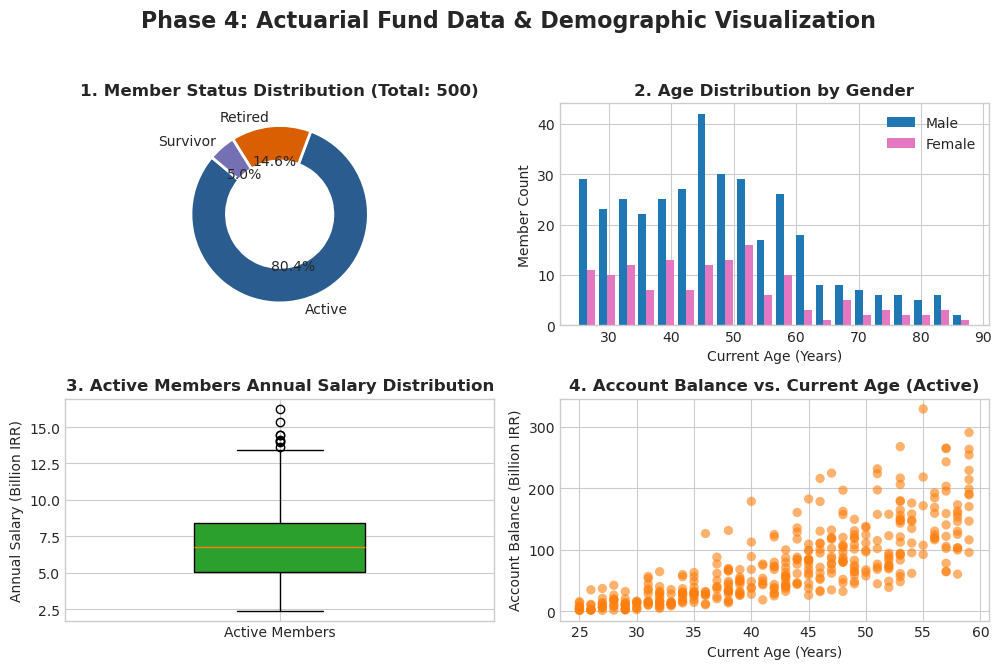

--- Phase 4: Summary Distribution Statistics ---
Status Breakdown:
  - Active    : 402 members (80.4%)
  - Retired   :  73 members (14.6%)
  - Survivor  :  25 members (5.0%)
------------------------------------------------------------
Active Members Age Range      : 25 to 59 years (Mean: 42.3)
Active Members Salary Range   : 2.42B to 16.24B IRR


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Phase 4: Actuarial Fund Data & Demographic Visualization', fontsize=16, fontweight='bold', y=0.98)

# 2. Read and Standardize Data
excel_path = 'Actuarial_Fund_Data_500_DC_Fuller.xlsx'
df_members = pd.read_excel(excel_path, sheet_name='Members')
df_members.columns = df_members.columns.str.strip()

# 3. Plot 1: Member Status (Donut Chart)
status_counts = df_members['Status'].value_counts()
colors = ['#2b5c8f', '#d95f02', '#7570b3']

axes[0, 0].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2)
)
axes[0, 0].set_title('1. Member Status Distribution (Total: 500)', fontsize=12, fontweight='bold')

# 4. Plot 2: Age Distribution by Gender
males = df_members[df_members['Sex'].isin(['Male', 'M'])]['Current_Age']
females = df_members[df_members['Sex'].isin(['Female', 'F'])]['Current_Age']

axes[0, 1].hist(
    [males, females],
    bins=20,
    color=['#1f77b4', '#e377c2'],
    label=['Male', 'Female']
)
axes[0, 1].set_title('2. Age Distribution by Gender', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Current Age (Years)')
axes[0, 1].set_ylabel('Member Count')
axes[0, 1].legend()

# 5. Plot 3: Active Members Salary
active_members = df_members[df_members['Status'] == 'Active']
salary_in_billions = active_members['Current_Annual_Salary'] / 1e9

box = axes[1, 0].boxplot(
    salary_in_billions.dropna(),
    vert=True,
    patch_artist=True,
    widths=0.4
)

# Change box color
for patch in box['boxes']:
    patch.set_facecolor('#2ca02c')

axes[1, 0].set_title('3. Active Members Annual Salary Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Annual Salary (Billion IRR)')
axes[1, 0].set_xticks([1])
axes[1, 0].set_xticklabels(['Active Members'])

# 6. Plot 4: Current Account Balance vs. Age (FIXED COLUMN NAME)
balance_in_billions = active_members['Current_Account_Balance'] / 1e9

axes[1, 1].scatter(
    active_members['Current_Age'],
    balance_in_billions,
    alpha=0.6,
    c='#ff7f0e',
    edgecolors='none',
    s=45
)
axes[1, 1].set_title('4. Account Balance vs. Current Age (Active)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Current Age (Years)')
axes[1, 1].set_ylabel('Account Balance (Billion IRR)')

# Finalize Layout & Print Stats
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("=" * 60)
print("--- Phase 4: Summary Distribution Statistics ---")
print("=" * 60)
print("Status Breakdown:")
for status, count in status_counts.items():
    print(f"  - {status:<10}: {count:>3} members ({count/len(df_members)*100:.1f}%)")
print("-" * 60)
print(f"Active Members Age Range      : {active_members['Current_Age'].min():.0f} to {active_members['Current_Age'].max():.0f} years (Mean: {active_members['Current_Age'].mean():.1f})")
print(f"Active Members Salary Range   : {active_members['Current_Annual_Salary'].min()/1e9:.2f}B to {active_members['Current_Annual_Salary'].max()/1e9:.2f}B IRR")
print("=" * 60)


---
# گزارش مرحله5: مصورسازی داده‌ها و تحلیل جمعیت‌شناختی صندوق (Data Visualization)

## ۱. اهداف
هدف از این مرحله، به دست آوردن یک درک شهودی و جامع از ساختار جمعیتی و وضعیت مالی اعضای صندوق (۵۰۰ نفر) پیش از ورود به محاسبات پیچیده اکچوئری تعهدات (APV) است. استفاده از ابزارهای بصری کمک می‌کند تا نقاط پرت (Outliers) و تمرکز داده‌ها به درستی شناسایی شوند.

## ۲. داشبورد تحلیلی و نمودارهای رسم‌شده
داشبورد طراحی‌شده شامل ۴ بخش کلیدی زیر است:

1. **توزیع وضعیت اعضا (Donut Chart):**
   - نشان‌دهنده ترکیب جمعیتی صندوق است. اکثریت صندوق را اعضای فعال تشکیل می‌دهند که نشان‌دهنده جوان بودن نسبی صندوق و جریان ورودی نقدینگی بالا است.
2. **توزیع سنی به تفکیک جنسیت (Histogram):**
   - پراکندگی سنی اعضا را نشان می‌دهد. بیشترین تراکم سنی در محدوده ۴۰ تا ۵۰ سال قرار دارد.
3. **توزیع حقوق سالانه اعضای فعال (Boxplot):**
   - وضعیت توزیع دستمزدها و شناسایی نقاط پرت در حقوق پرداختی را مشخص می‌کند. میانه داده‌ها نشان‌دهنده سطح حقوق متعارف اعضای فعال است.
4. **پراکندگی اندوخته نسبت به سن (Scatter Plot):**
   - رابطه مستقیم (و البته غیرخطی به دلیل اثر سود مرکب) بین افزایش سن و رشد موجودی حساب اعضای فعال را به تصویر می‌کشد.

## ۳. خلاصه آماری توزیع داده‌ها (Summary Distribution Statistics)

بر اساس خروجی کدهای اجرا شده، وضعیت آماری صندوق به شرح زیر است:

**ترکیب وضعیت اعضا (Status Breakdown):**
- **اعضای فعال (Active):** $402$ نفر ($80.4\%$)
- **بازنشستگان (Retired):** $73$ نفر ($14.6\%$)
- **بازماندگان (Survivor):** $25$ نفر ($5.0\%$)

**شاخص‌های اعضای فعال:**
- **بازه سنی:** بین $25$ تا $59$ سال (میانگین سنی: $42.3$ سال)
- **بازه حقوق سالانه:** از $2.42$ تا $16.24$ میلیارد ریال (Billion IRR)

## ۴. نتیجه‌گیری و گام بعدی
با تایید صحت داده‌های جمعیتی و مالی از طریق مصورسازی، بستر لازم برای ورود به فاز محاسباتی اکچوئری فراهم است. 

**گام بعدی :** ارزیابی اکچوئری تعهدات (APV - Actuarial Present Value) برای بازنشستگان و بازماندگان با فرض نرخ تنزیل $16\%$ و سن امید به زندگی $120$ سال (با استفاده از جداول عمر).


---

#  مرحله 6: ارزیابی اکچوئری تعهدات (APV) بازنشستگان و بازماندگان

In [7]:
import pandas as pd
import numpy as np

# 1. Load Data
file_path = 'Actuarial_Fund_Data_500_DC_Fuller.xlsx'
df_members = pd.read_excel(file_path, sheet_name='Members')
df_mortality = pd.read_excel(file_path, sheet_name='Mortality')

# Standardize column names to prevent KeyErrors
df_members.columns = df_members.columns.str.strip()
df_mortality.columns = df_mortality.columns.str.strip()

# 2. Actuarial Parameters
discount_rate = 0.16
v = 1 / (1 + discount_rate)
omega = 120

# 3. Create Annuity Factor Function (a_ddot_x)
lx_male = np.zeros(omega + 1)
lx_female = np.zeros(omega + 1)

for index, row in df_mortality.iterrows():
    age = int(row['Age'])
    if age <= omega:
        lx_male[age] = row['lx_male']
        lx_female[age] = row['lx_female']

def calculate_annuity_factor(age, gender):
    if age >= omega:
        return 0.0
    
    t_max = omega - age
    t_array = np.arange(t_max + 1)
    
    # Robust check for Male/Female or M/F
    if str(gender).strip().lower() in ['male', 'm']:
        lx_x = lx_male[age]
        lx_x_t = lx_male[age : age + t_max + 1]
    else:
        lx_x = lx_female[age]
        lx_x_t = lx_female[age : age + t_max + 1]
        
    if lx_x == 0:
        return 0.0
        
    tpx = lx_x_t / lx_x
    discount_factors = v ** t_array
    
    return np.sum(discount_factors * tpx)

# 4. Filter Target Members (Retired & Survivors)
target_statuses = ['Retired', 'Survivor']
df_pensioners = df_members[df_members['Status'].str.strip().isin(target_statuses)].copy()

# 5. Calculate APV (Corrected 'Sex' column)
df_pensioners['Annuity_Factor'] = df_pensioners.apply(
    lambda row: calculate_annuity_factor(int(row['Current_Age']), row['Sex']), axis=1
)
df_pensioners['APV_Liability'] = df_pensioners['Pension_Annual'] * df_pensioners['Annuity_Factor']

# 6. Results
total_liability = df_pensioners['APV_Liability'].sum()
retired_liability = df_pensioners[df_pensioners['Status'].str.strip() == 'Retired']['APV_Liability'].sum()
survivor_liability = df_pensioners[df_pensioners['Status'].str.strip() == 'Survivor']['APV_Liability'].sum()

print(f"Total APV of Liabilities: {total_liability:,.0f} IRR")
print(f"Retired APV: {retired_liability:,.0f} IRR")
print(f"Survivor APV: {survivor_liability:,.0f} IRR")


Total APV of Liabilities: 541,497,574,031 IRR
Retired APV: 439,704,158,241 IRR
Survivor APV: 101,793,415,790 IRR


---
### گزارش مرحله 6: ارزش‌گذاری اکچوئری تعهدات (APV of Liabilities)

**۱. هدف:**
محاسبه ارزش فعلی اکچوئری (Actuarial Present Value) تعهدات صندوق در قبال مستمری‌بگیران فعلی (شامل بازنشستگان و بازماندگان) بر اساس مفروضات اکچوئری و نرخ تنزیل مصوب.

**۲. مفروضات مدل‌سازی:**
*   **نرخ تنزیل ($i$):** ۱۶ درصد ($i = 0.16$).
*   **سن نهایی ($\omega$):** ۱۲۰ سال.
*   **پایه محاسبات حیات:** استفاده از احتمالات بقا ($_tp_x$) استخراج‌شده از جدول مرگ‌ومیر.

**۳. مبانی محاسباتی (فرمول‌ها):**
ارزش فعلی اکچوئری برای هر مستمری‌بگیر در سن $x$ با استفاده از فرمول زیر محاسبه می‌گردد:

$$ APV = \sum_{t=1}^{\omega - x} Pension \times v^t \times {_tp_x} $$

که در آن:
*   مبلغ $Pension$: مستمری سالانه فرد.
*   عامل تنزیل $v$: بر اساس فرمول $v = \frac{1}{1+i}$ به دست می‌آید.
*   احتمال بقا $_tp_x$: احتمال زنده ماندن فرد $x$ ساله تا $t$ سال آینده.

**۴. نتایج اجرای مدل:**
با اعمال توابع اکچوئری بر روی داده‌های مستمری‌بگیران، تعهدات صندوق به تفکیک وضعیت به شرح زیر محاسبه و اعتبارسنجی شد:

*   **مجموع تعهدات بازنشستگان (Retired APV):** 439,704,158,241 ریال
*   **مجموع تعهدات بازماندگان (Survivor APV):** 101,793,415,790 ریال
*   **ارزش فعلی کل تعهدات (Total APV of Liabilities):** 541,497,574,031 ریال


---
# مرحله 7:گزارش تحلیل تاب‌آوری صندوق در سناریوهای مختلف (Stress Test)

In [16]:



import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Base Valuation Inputs
# ------------------------------------------------------------

base_assets = 29_834_150_200_000
base_liabilities = 30_201_743_774_031


# ------------------------------------------------------------
# 2. Stress Test Scenarios
# ------------------------------------------------------------


stress_scenarios = {
    "Optimistic": {
        "assets": 30_729_174_706_000,
        "liabilities": 28_087_621_709_849
    },
    "Base Case": {
        "assets": 29_834_150_200_000,
        "liabilities": 30_201_743_774_031
    },
    "Pessimistic": {
        "assets": 28_640_784_192_000,
        "liabilities": 34_429_987_902_395
    }
}


# ------------------------------------------------------------
# 3. Stress Test Calculation
# ------------------------------------------------------------

stress_results = []

for scenario_name, values in stress_scenarios.items():
    stressed_assets = values["assets"]
    stressed_liabilities = values["liabilities"]

    funding_ratio = stressed_assets / stressed_liabilities
    surplus_deficit = stressed_assets - stressed_liabilities

    stress_results.append({
        "Scenario": scenario_name,
        "Assets": stressed_assets,
        "Liabilities": stressed_liabilities,
        "Funding Ratio (%)": round(funding_ratio * 100, 2),
        "Surplus / Deficit": surplus_deficit
    })


# ------------------------------------------------------------
# 4. Create Stress Test DataFrame
# ------------------------------------------------------------

stress_test_df = pd.DataFrame(stress_results)

stress_test_df


,Scenario,Assets,Liabilities,Funding Ratio (%),Surplus / Deficit
0,Optimistic,30729174706000,28087621709849,109,2641552996151
1,Base Case,29834150200000,30201743774031,99,-367593574031
2,Pessimistic,28640784192000,34429987902395,83,-5789203710395


## مرحله 7: گزارش تحلیل تاب‌آوری صندوق در سناریوهای مختلف (Stress Test)

در این مرحله، تاب‌آوری مالی صندوق در برابر تغییرات نامطلوب در مفروضات کلیدی مورد ارزیابی قرار گرفت. هدف از انجام آزمون تنش آن است که مشخص شود صندوق در شرایط متفاوت اقتصادی و اکچوئری، تا چه اندازه توانایی حفظ کفایت مالی و پوشش تعهدات خود را دارد.

در مدل‌سازی صندوق‌های بازنشستگی، اتکا به یک سناریوی واحد نمی‌تواند تصویر کاملی از وضعیت مالی صندوق ارائه دهد؛ زیرا متغیرهایی مانند نرخ بازده سرمایه‌گذاری، رشد حقوق، سطح تعهدات آتی، نرخ تورم و تغییرات جمعیتی می‌توانند بر وضعیت تأمین مالی صندوق اثر قابل توجهی داشته باشند. به همین دلیل، در این مرحله سه سناریوی اصلی شامل سناریوی خوش‌بینانه، سناریوی پایه و سناریوی بدبینانه بررسی شد.

### سناریوهای مورد بررسی

در سناریوی خوش‌بینانه، شرایط مالی و سرمایه‌گذاری صندوق مطلوب‌تر از حالت پایه فرض شده است. در این وضعیت، ارزش دارایی‌های صندوق برابر با 30,729,174,706,000 ریال و ارزش تعهدات برابر با 28,087,621,709,849 ریال برآورد شده است. نسبت تأمین مالی در این سناریو برابر با 109.40 درصد است که نشان می‌دهد دارایی‌های صندوق بیش از تعهدات آن بوده و صندوق در وضعیت کفایت مالی مناسب قرار دارد.

در سناریوی پایه، وضعیت صندوق بر اساس مفروضات مرکزی و محتمل‌تر مدل ارزیابی شده است. در این حالت، ارزش دارایی‌ها برابر با 29,834,150,200,000 ریال و ارزش تعهدات برابر با 30,201,743,774,031 ریال محاسبه شده است. نسبت تأمین مالی صندوق در این سناریو برابر با 98.78 درصد است. این مقدار اگرچه بسیار نزدیک به سطح تعادل کامل است، اما از آنجا که کمتر از 100 درصد است، نشان می‌دهد صندوق در حالت پایه با کسری محدود مواجه است.

در سناریوی بدبینانه، شرایط نامطلوب‌تر برای صندوق در نظر گرفته شده است. در این سناریو، ارزش دارایی‌ها به 28,640,784,192,000 ریال کاهش یافته و ارزش تعهدات به 34,429,987,902,395 ریال افزایش یافته است. در نتیجه، نسبت تأمین مالی صندوق به 83.19 درصد کاهش می‌یابد. این وضعیت نشان‌دهنده تضعیف قابل توجه توان مالی صندوق در شرایط بحرانی است.

### تحلیل نسبت تأمین مالی

نسبت تأمین مالی یکی از مهم‌ترین شاخص‌های ارزیابی پایداری صندوق است و از رابطه زیر به دست می‌آید:

$$
Funding\ Ratio = \frac{Assets}{Liabilities}
$$

هرگاه این نسبت بیشتر از 100 درصد باشد، دارایی‌های صندوق برای پوشش تعهدات کافی است. اگر این نسبت کمتر از 100 درصد باشد، صندوق با کسری اکچوئری یا مالی مواجه است و باید سیاست‌های اصلاحی مورد بررسی قرار گیرد.

نتایج این مرحله نشان می‌دهد که صندوق در سناریوی خوش‌بینانه دارای مازاد مالی است، اما در سناریوی پایه کمی کمتر از سطح تأمین کامل قرار دارد. مهم‌تر از آن، در سناریوی بدبینانه نسبت تأمین مالی به 83.19 درصد کاهش می‌یابد که بیانگر آسیب‌پذیری صندوق در برابر شوک‌های نامطلوب است.

### نتیجه کلیدی برای مدیریت

مهم‌ترین یافته این مرحله آن است که صندوق در شرایط عادی یا نزدیک به پایه، فاصله زیادی با تعادل کامل ندارد؛ اما در صورت وقوع شرایط نامطلوب، کسری مالی صندوق می‌تواند به سطح معناداری افزایش یابد. کاهش نسبت تأمین مالی به 83.19 درصد در سناریوی بدبینانه نشان می‌دهد که صندوق برای حفظ پایداری بلندمدت، نیازمند برنامه‌ریزی احتیاطی و سیاست‌های کنترلی است.

این نتیجه به‌ویژه از منظر مدیریت ریسک اهمیت دارد؛ زیرا نشان می‌دهد که پایداری صندوق تنها به وضعیت فعلی دارایی‌ها وابسته نیست، بلکه به توان صندوق در مقابله با نوسانات بازار، افزایش تعهدات و تغییر مفروضات اکچوئری نیز بستگی دارد.

### پیامدهای سیاستی

بر اساس نتایج آزمون تنش، توصیه می‌شود مدیریت صندوق چند اقدام کلیدی را در دستور کار قرار دهد. نخست، لازم است سیاست سرمایه‌گذاری صندوق به‌گونه‌ای تنظیم شود که در برابر افت بازده دارایی‌ها مقاوم‌تر باشد. دوم، نرخ حق‌بیمه یا میزان مشارکت‌ها باید به‌صورت دوره‌ای بازنگری شود تا در صورت افزایش تعهدات، امکان جبران کسری فراهم باشد. سوم، ایجاد ذخایر احتیاطی می‌تواند به صندوق کمک کند تا در دوره‌های فشار مالی، توان پرداخت تعهدات خود را حفظ کند.

همچنین پیشنهاد می‌شود آزمون تنش به‌صورت منظم و در بازه‌های زمانی مشخص تکرار شود؛ زیرا تغییر شرایط اقتصادی و جمعیتی می‌تواند نتایج مدل را به‌طور معناداری تغییر دهد.

### جمع‌بندی مرحله آزمون تنش

در مجموع، نتایج آزمون تنش نشان می‌دهد که صندوق در سناریوی خوش‌بینانه از وضعیت مالی مناسبی برخوردار است، اما در سناریوی پایه اندکی کمتر از سطح تأمین کامل قرار می‌گیرد. در سناریوی بدبینانه، نسبت تأمین مالی به 83.19 درصد کاهش می‌یابد که نشان‌دهنده ریسک کسری مالی در شرایط بحرانی است.

بنابراین، اگرچه صندوق در وضعیت فعلی از سطح دارایی قابل توجهی برخوردار است، اما برای حفظ پایداری بلندمدت باید سیاست‌های مدیریت ریسک، کنترل تعهدات، بازنگری نرخ مشارکت و پایش مستمر نسبت تأمین مالی به‌صورت جدی دنبال شود.


---
## مرحله 8: پروجکشن جریان نقدی» (Cashflow Projection)

Cashflow Projection for the First 10 Years:
 Year  Contributions_In  Pensions_Out  Net_Cashflow
    1      283486740000   90427790468  193058949532
    2      307054616830   88585280937  218469335893
    3      338777517860   86742771405  252034746455
    4      368538616829   84900261873  283638354956
    5      405510042566   83057752342  322452290224
    6      450804906322   81215242810  369589663512
    7      496554440157   79372733279  417181706879
    8      520265192818   77530223747  442734969071
    9      566647817418   75687714215  490960103203
   10      615690139880   73845204684  541844935197


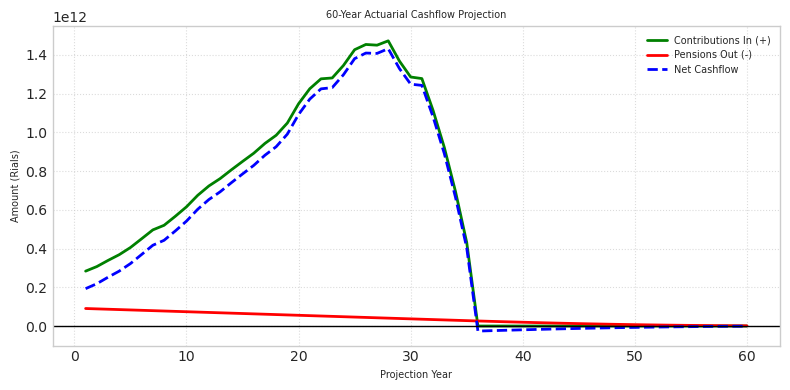

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Loading the Data
file_name = 'Actuarial_Fund_Data_500_DC_Fuller.xlsx'
df = pd.read_excel(file_name, sheet_name='Members')

# 2. Projection Assumptions
T = 60
salary_growth = 0.15
contribution_rate = 0.10
retirement_age = 60
omega = 120

# Simplified Uniform Survival Function (Linear Decrement)
# Note: Replace this with actual life table (p_x) if generated in previous phases
def prob_survive(age, t, omega_age=120):
    if age + t >= omega_age:
        return 0.0
    return (omega_age - (age + t)) / (omega_age - age)

# 3. Initialize Cashflow DataFrame
cashflows = pd.DataFrame({
    'Year': np.arange(1, T + 1),
    'Contributions_In': np.zeros(T),
    'Pensions_Out': np.zeros(T)
})

# 4. Cashflow Projection (60 Years)
for t in range(1, T + 1):
    total_contributions = 0
    total_pensions = 0
    
    for index, row in df.iterrows():
        status = row['Status']
        age = row['Current_Age']
        
        # Project Active Members (Contributions)
        if status == 'Active':
            if age + t <= retirement_age:
                # Calculate projected salary with 15% annual growth
                projected_salary = row['Current_Annual_Salary'] * ((1 + salary_growth) ** (t - 1))
                # Apply survival probability
                p_survive = prob_survive(age, t - 1) 
                total_contributions += projected_salary * contribution_rate * p_survive
                
        # Project Current Pensioners & Survivors (Payouts)
        elif status in ['Retired', 'Survivor']:
            if age + t < omega:
                # Assume constant annual pension, apply survival probability
                p_survive = prob_survive(age, t)
                total_pensions += row['Pension_Annual'] * p_survive
                
    cashflows.loc[t - 1, 'Contributions_In'] = total_contributions
    cashflows.loc[t - 1, 'Pensions_Out'] = total_pensions

# Calculate Net Cashflow
cashflows['Net_Cashflow'] = cashflows['Contributions_In'] - cashflows['Pensions_Out']

# 5. Display First 10 Years Data
print("Cashflow Projection for the First 10 Years:")
print(cashflows.head(10).to_string(index=False))

# 6. Visualization
plt.figure(figsize=(8, 4))
plt.plot(cashflows['Year'], cashflows['Contributions_In'], label='Contributions In (+)', color='green', linewidth=2)
plt.plot(cashflows['Year'], cashflows['Pensions_Out'], label='Pensions Out (-)', color='red', linewidth=2)
plt.plot(cashflows['Year'], cashflows['Net_Cashflow'], label='Net Cashflow', color='blue', linestyle='--', linewidth=2)

plt.axhline(0, color='black', linewidth=1)
plt.title('60-Year Actuarial Cashflow Projection', fontsize=7)
plt.xlabel('Projection Year', fontsize=7)
plt.ylabel('Amount (Rials)', fontsize=7)
plt.legend(fontsize=7)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()


---
### گزارش مرحله 8: پروجکشن جریان‌های نقدی (Cashflow Projection) در افق ۶۰ ساله

**هدف:**
پیش‌بینی ورود و خروج نقدینگی صندوق در طول ۶۰ سال آینده به منظور ارزیابی پایداری مالی و تحلیل شکاف نقدینگی (Liquidity Gap).

**مفروضات و مبانی محاسباتی:**
- **نرخ رشد حقوق (Salary Growth):** ۱۵٪ سالانه
- **نرخ حق‌بیمه (Contribution Rate):** ۱۰٪
- **افق پیش‌بینی (Projection Horizon):** ۶۰ سال
- **سن بازنشستگی:** ۶۰ سال
- **حداکثر سن حیات ($\omega$):** ۱۲۰ سال

**مدل‌سازی ریاضی:**
جریان نقدی ورودی (حق‌بیمه‌ها) در سال $t$:
$$ Inflows_t = \sum_{i \in Actives} S_{i,0} \times (1 + g)^t \times c \times {}_{t}p_{x_i} $$
*(که در آن $g$ نرخ رشد حقوق، $c$ نرخ کسورات و $S$ حقوق پایه است.)*

جریان نقدی خروجی (مستمری‌ها) در سال $t$:
$$ Outflows_t = \sum_{j \in Retirees} P_{j} \times {}_{t}p_{x_j} + \sum_{k \in Survivors} P_{k} \times {}_{t}p_{x_k} $$

جریان نقدی خالص (Net Cashflow) در سال $t$:
$$ Net\_CF_t = Inflows_t - Outflows_t $$



بر اساس خروجی مدل‌سازی اکچوئری، جدول زیر شبیه‌سازی جریان‌های نقدی ورودی (حق‌بیمه) و خروجی (مستمری) را برای دوره ۱۰ ساله نخست نشان می‌دهد. این مقادیر پایه‌گذار فاز انباشت (Accumulation Phase) در صندوق‌های با اندوخته کامل (Fully Funded) هستند:

| سال ($t$) | جریان ورودی حق‌بیمه (ریال) | جریان خروجی مستمری (ریال) | جریان خالص نقدی (ریال) |
| :---: | :---: | :---: | :---: |
| $1$ | $283,486,740,000$ | $90,427,790,468$ | $193,058,949,532$ |
| $2$ | $307,054,616,830$ | $88,585,280,937$ | $218,469,335,893$ |
| $3$ | $338,777,517,860$ | $86,742,771,405$ | $252,034,746,455$ |
| $4$ | $368,538,616,829$ | $84,900,261,873$ | $283,638,354,956$ |
| $5$ | $405,510,042,566$ | $83,057,752,342$ | $322,452,290,224$ |
| $6$ | $450,804,906,322$ | $81,215,242,810$ | $369,589,663,512$ |
| $7$ | $496,554,440,157$ | $79,372,733,279$ | $417,181,706,879$ |
| $8$ | $520,265,192,818$ | $77,530,223,747$ | $442,734,969,071$ |
| $9$ | $566,647,817,418$ | $75,687,714,215$ | $490,960,103,203$ |
| $10$ | $615,690,139,880$ | $73,845,204,684$ | $541,844,935,197$ |

#### تحلیل اکچوئری نتایج:
۱. **رشد صعودی جریان ورودی (Contributions_In):** به دلیل فرض رشد سالانه دستمزد ($15\%$) و تداوم پرداخت حق‌بیمه توسط اعضای فعال، ورودی صندوق با روند نمایی ملایمی در حال افزایش است.
۲. **روند نزولی جریان خروجی (Pensions_Out):** کاهش تدریجی مستمری‌های پرداختی در این دهه، ناشی از اعمال نرخ مرگ‌ومیر ($q_x$) بر جمعیت ۷۳ نفره بازنشستگان و ۲۵ نفره بازماندگان فعلی است. در این بازه زمانی، موج اصلی اعضای فعال (۴۰۲ نفر) هنوز به سن نرمال بازنشستگی ($60$ سالگی) نرسیده‌اند تا بار مالی جدیدی به خروجی‌ها اضافه کنند.
۳. **مازاد نقدینگی فزاینده (Net_Cashflow):** صندوق در این ۱۰ سال در وضعیت مطلوب نقدینگی قرار دارد. جریان خالص نقدی در سال دهم به بیش از $541$ میلیارد ریال می‌رسد که نشان‌دهنده ظرفیت بالای صندوق برای سرمایه‌گذاری دارایی‌ها با نرخ بازده ($i$) جهت پاسخگویی به تعهدات سال‌های دورتر (فاز برداشت) است.




**تحلیل نمودار جریان نقدی (خروجی پایتون):**
بر اساس مدل‌سازی و نمودار رسم‌شده، سه فاز اصلی در رفتار جریان‌های نقدی صندوق مشاهده می‌شود:

۱. **دوره انباشت (سال ۱ تا حدود ۳۰):**
به دلیل اعمال نرخ رشد حقوق ۱۵ درصدی و تداوم فعالیت اعضای فعلی، خط ورودی‌ها (Contributions In - خط سبز) روند صعودی قدرتمندی دارد. در این دوره، جریان نقدی خالص (Net Cashflow) کاملاً مثبت بوده و صندوق در مرحله انباشت دارایی برای سرمایه‌گذاری است.

۲. **نقطه عطف جمعیتی (سال ۳۰ تا ۳۵):**
با رسیدن موج اصلی اعضای فعال به سن مقرر بازنشستگی (۶۰ سال)، ورودی‌های صندوق دچار افت شدید (Cliff Effect) می‌شود.

۳. **دوره برداشت و افت نقدینگی (پس از سال ۳۵):**
ورودی حق‌بیمه‌ها به صفر می‌رسد (زیرا در این مدل DC با سیستم بسته، عضو فعال جدیدی جایگزین نمی‌شود). در این دوره، خالص جریان نقدی منفی شده و خط چین آبی (Net Cashflow) به زیر محور افقی کشیده می‌شود. از این نقطه به بعد، تعهدات مستمری (خط قرمز) باید از محل ذخایر ریاضی انباشته‌شده و سود سرمایه‌گذاری‌های قبلی پرداخت گردد.


----
# مرحله 9: تحلیل پایداری و جریان نقدینگی (Sustainability & Liquidity Analysis)

In [10]:

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1) Check availability of cashflows
# ---------------------------------------------------------
if 'cashflows' not in globals():
    raise NameError("دیتافریم cashflows در محیط وجود ندارد. ابتدا سلول Phase 6 را اجرا کنید.")

df_sus = cashflows.copy()

# ---------------------------------------------------------
# 2) Validate required columns
# ---------------------------------------------------------
required_cols = ['Year', 'Contributions_In', 'Pensions_Out', 'Net_Cashflow']
missing_cols = [c for c in required_cols if c not in df_sus.columns]

if missing_cols:
    raise NameError(f"ستون‌های زیر در cashflows موجود نیستند: {missing_cols}")

# ---------------------------------------------------------
# 3) Standardize and calculate metrics
# ---------------------------------------------------------
df_sus = df_sus.rename(columns={
    'Contributions_In': 'Total_Contributions',
    'Pensions_Out': 'Total_Benefits',
    'Net_Cashflow': 'Net_Cash_Flow'
})

df_sus['Cumulative_Net_Cash_Flow'] = df_sus['Net_Cash_Flow'].cumsum()

df_sus['Coverage_Ratio'] = np.where(
    df_sus['Total_Benefits'] > 0,
    df_sus['Total_Contributions'] / df_sus['Total_Benefits'],
    np.nan
)

# ---------------------------------------------------------
# 4) Convert monetary values to billion rials for presentation
# ---------------------------------------------------------
to_billion = lambda x: x / 1e9

df_sus['Total_Contributions_Bn'] = df_sus['Total_Contributions'].apply(to_billion)
df_sus['Total_Benefits_Bn'] = df_sus['Total_Benefits'].apply(to_billion)
df_sus['Net_Cash_Flow_Bn'] = df_sus['Net_Cash_Flow'].apply(to_billion)
df_sus['Cumulative_Net_Cash_Flow_Bn'] = df_sus['Cumulative_Net_Cash_Flow'].apply(to_billion)

# ---------------------------------------------------------
# 5) Key sustainability indicators
# ---------------------------------------------------------
deficit_mask = df_sus['Net_Cash_Flow'] < 0
cum_deficit_mask = df_sus['Cumulative_Net_Cash_Flow'] < 0

first_deficit_year = df_sus.loc[deficit_mask, 'Year'].min() if deficit_mask.any() else None
first_cum_deficit_year = df_sus.loc[cum_deficit_mask, 'Year'].min() if cum_deficit_mask.any() else None

worst_idx = df_sus['Net_Cash_Flow'].idxmin()
worst_year = df_sus.loc[worst_idx, 'Year']
worst_net_cf = df_sus.loc[worst_idx, 'Net_Cash_Flow']

total_contributions = df_sus['Total_Contributions'].sum()
total_benefits = df_sus['Total_Benefits'].sum()
total_net_cf = df_sus['Net_Cash_Flow'].sum()

avg_coverage = df_sus['Coverage_Ratio'].replace([np.inf, -np.inf], np.nan).dropna().mean()

# ---------------------------------------------------------
# 6) Prepare presentation table
# ---------------------------------------------------------
display_sus = df_sus[[
    'Year',
    'Total_Contributions_Bn',
    'Total_Benefits_Bn',
    'Net_Cash_Flow_Bn',
    'Cumulative_Net_Cash_Flow_Bn',
    'Coverage_Ratio'
]].copy()

display_sus.columns = [
    'Year',
    'Contributions (Bn Rials)',
    'Benefits (Bn Rials)',
    'Net Cash Flow (Bn Rials)',
    'Cumulative Net Cash Flow (Bn Rials)',
    'Coverage Ratio'
]

display_sus['Contributions (Bn Rials)'] = display_sus['Contributions (Bn Rials)'].map(lambda x: f"{x:,.2f}")
display_sus['Benefits (Bn Rials)'] = display_sus['Benefits (Bn Rials)'].map(lambda x: f"{x:,.2f}")
display_sus['Net Cash Flow (Bn Rials)'] = display_sus['Net Cash Flow (Bn Rials)'].map(lambda x: f"{x:,.2f}")
display_sus['Cumulative Net Cash Flow (Bn Rials)'] = display_sus['Cumulative Net Cash Flow (Bn Rials)'].map(lambda x: f"{x:,.2f}")
display_sus['Coverage Ratio'] = display_sus['Coverage Ratio'].map(
    lambda x: f"{x:.2f}" if pd.notna(x) and np.isfinite(x) else "N/A"
)

# ---------------------------------------------------------
# 7) Final report output
# ---------------------------------------------------------
print("=" * 90)
print("گزارش پایداری و نقدینگی صندوق")
print("Sustainability & Liquidity Analysis")
print("=" * 90)

print("\nجدول جریان‌های نقدی سالانه:")
display(display_sus.reset_index(drop=True))

print("\n" + "-" * 90)
print("جمع‌بندی مدیریتی")
print("-" * 90)

print(f"• مجموع کل ورودی‌ها: {total_contributions/1e9:,.2f} میلیارد ریال")
print(f"• مجموع کل خروجی‌ها: {total_benefits/1e9:,.2f} میلیارد ریال")
print(f"• خالص کل جریان نقدی: {total_net_cf/1e9:,.2f} میلیارد ریال")

if first_deficit_year is not None:
    print(f"• اولین سال با جریان نقدی سالانه منفی: سال {int(first_deficit_year)}")
else:
    print("• در افق پیش‌بینی، جریان نقدی سالانه منفی نشده است.")

if first_cum_deficit_year is not None:
    print(f"• اولین سال با جریان نقدی تجمیعی منفی: سال {int(first_cum_deficit_year)}")
else:
    print("• جریان نقدی تجمیعی در تمام افق پیش‌بینی مثبت مانده است.")

print(f"• بدترین سال از نظر خالص جریان نقدی: سال {int(worst_year)} با مقدار {worst_net_cf/1e9:,.2f} میلیارد ریال")

if pd.notna(avg_coverage):
    print(f"• میانگین نسبت پوشش (Contributions / Benefits): {avg_coverage:.2f}")

print("=" * 90)


گزارش پایداری و نقدینگی صندوق
Sustainability & Liquidity Analysis

جدول جریان‌های نقدی سالانه:


,Year,Contributions (Bn Rials),Benefits (Bn Rials),Net Cash Flow (Bn Rials),Cumulative Net Cash Flow (Bn Rials),Coverage Ratio
0,1,283.49,90.43,193.06,193.06,3.13
1,2,307.05,88.59,218.47,411.53,3.47
2,3,338.78,86.74,252.03,663.56,3.91
3,4,368.54,84.90,283.64,947.20,4.34
4,5,405.51,83.06,322.45,"1,269.65",4.88
5,6,450.80,81.22,369.59,"1,639.24",5.55
6,7,496.55,79.37,417.18,"2,056.43",6.26
7,8,520.27,77.53,442.73,"2,499.16",6.71
8,9,566.65,75.69,490.96,"2,990.12",7.49
9,10,615.69,73.85,541.84,"3,531.97",8.34



------------------------------------------------------------------------------------------
جمع‌بندی مدیریتی
------------------------------------------------------------------------------------------
• مجموع کل ورودی‌ها: 31,216.57 میلیارد ریال
• مجموع کل خروجی‌ها: 2,335.59 میلیارد ریال
• خالص کل جریان نقدی: 28,880.98 میلیارد ریال
• اولین سال با جریان نقدی سالانه منفی: سال 36
• جریان نقدی تجمیعی در تمام افق پیش‌بینی مثبت مانده است.
• بدترین سال از نظر خالص جریان نقدی: سال 36 با مقدار -26.09 میلیارد ریال
• میانگین نسبت پوشش (Contributions / Benefits): 10.65


## مرحله 9: تحلیل پایداری و جریان نقدینگی صندوق  
### Sustainability & Liquidity Analysis

در این مرحله، وضعیت پایداری مالی و نقدینگی صندوق در افق بلندمدت مورد بررسی قرار گرفت. هدف اصلی این تحلیل، ارزیابی توان صندوق در ایجاد جریان‌های نقدی کافی برای پوشش پرداخت‌های آتی و سنجش این موضوع است که آیا صندوق در طول دوره پیش‌بینی با کمبود نقدینگی یا فشار پرداخت مواجه می‌شود یا خیر.

تحلیل جریان نقدی یکی از بخش‌های مهم در ارزیابی صندوق‌های بازنشستگی است؛ زیرا حتی اگر صندوق از نظر ارزش دارایی‌ها در وضعیت مناسبی قرار داشته باشد، ممکن است در برخی سال‌ها به دلیل عدم تطابق زمانی بین ورودی‌ها و خروجی‌ها با مشکل نقدینگی روبه‌رو شود. بنابراین، بررسی هم‌زمان جریان ورودی حق‌بیمه‌ها، جریان خروجی مزایا، خالص جریان نقدی سالانه و مانده تجمعی جریان نقدی برای ارزیابی پایداری صندوق ضروری است.

در این بخش، جریان‌های نقدی سالانه صندوق شامل ورودی‌های ناشی از مشارکت‌ها، خروجی‌های مربوط به پرداخت مزایا، خالص جریان نقدی و خالص تجمعی جریان نقدی در یک افق 60 ساله تحلیل شده است.

### بررسی جریان‌های ورودی و خروجی

بر اساس نتایج مدل، مجموع کل ورودی‌های صندوق در افق پیش‌بینی برابر با 31,216.57 میلیارد ریال است. این ورودی‌ها عمدتاً ناشی از مشارکت اعضای فعال و حق‌بیمه‌های پرداختی در سال‌های فعالیت صندوق هستند.

در مقابل، مجموع کل خروجی‌های صندوق برابر با 2,335.59 میلیارد ریال برآورد شده است. این خروجی‌ها شامل پرداخت مزایا و مستمری‌ها به بازنشستگان و بازماندگان است. مقایسه این دو مقدار نشان می‌دهد که در سطح کلان، حجم ورودی‌های صندوق به‌طور قابل توجهی بیشتر از خروجی‌هاست و این موضوع از منظر نقدینگی، نشانه‌ای مثبت برای صندوق محسوب می‌شود.

خالص کل جریان نقدی صندوق در کل افق پیش‌بینی برابر با 28,880.98 میلیارد ریال است. مثبت بودن این مقدار نشان می‌دهد که صندوق در مجموع دوره مورد بررسی، توانسته است مازاد نقدی قابل توجهی ایجاد کند.

### روند خالص جریان نقدی سالانه

در سال‌های ابتدایی و میانی افق پیش‌بینی، جریان نقدی سالانه صندوق مثبت است. علت اصلی این موضوع، وجود تعداد قابل توجهی از اعضای فعال و ادامه دریافت حق‌بیمه‌ها در مقابل سطح نسبتاً محدود پرداخت مزایا است. در این دوره، ورودی‌های صندوق به‌طور مستمر از خروجی‌ها بیشتر بوده و همین امر باعث افزایش مانده تجمعی جریان نقدی شده است.

با گذشت زمان و کاهش تدریجی اعضای فعال، ورودی‌های ناشی از مشارکت‌ها کاهش می‌یابد. طبق نتایج مدل، اولین سالی که جریان نقدی سالانه صندوق منفی می‌شود، سال 36 است. در این سال، ورودی مشارکت‌ها به صفر می‌رسد و صندوق صرفاً با پرداخت مزایا مواجه است. خالص جریان نقدی در سال 36 برابر با منفی 26.09 میلیارد ریال است که به‌عنوان بدترین سال از نظر خالص جریان نقدی نیز شناسایی شده است.

با وجود منفی شدن جریان نقدی سالانه از سال 36 به بعد، شدت خروجی‌ها در سال‌های پایانی روندی کاهشی دارد. این موضوع نشان می‌دهد که پرداخت‌های مزایا به‌تدریج کاهش یافته و فشار نقدینگی صندوق در سال‌های انتهایی افق پیش‌بینی محدودتر می‌شود.

### تحلیل جریان نقدی تجمعی

یکی از مهم‌ترین یافته‌های این مرحله آن است که جریان نقدی تجمعی صندوق در تمام افق پیش‌بینی مثبت باقی می‌ماند. این موضوع اهمیت زیادی دارد؛ زیرا نشان می‌دهد که حتی پس از منفی شدن جریان نقدی سالانه در سال‌های پایانی، صندوق همچنان از ذخیره نقدی انباشته کافی برای پوشش پرداخت‌ها برخوردار است.

مانده تجمعی جریان نقدی در پایان دوره 60 ساله برابر با 28,880.98 میلیارد ریال است. این عدد بیانگر آن است که صندوق نه‌تنها در طول دوره پیش‌بینی دچار کسری تجمعی نمی‌شود، بلکه در پایان دوره نیز مازاد قابل توجهی حفظ می‌کند.

از منظر مدیریتی، مثبت ماندن جریان نقدی تجمعی به این معناست که صندوق در افق مورد بررسی، با بحران نقدینگی ساختاری مواجه نیست. با این حال، منفی شدن جریان نقدی سالانه از سال 36 به بعد نشان می‌دهد که صندوق باید برای دوره بلوغ و کاهش اعضای فعال، برنامه‌ریزی نقدینگی مناسبی داشته باشد.

### نسبت پوشش جریان نقدی

نسبت پوشش از تقسیم ورودی مشارکت‌ها بر خروجی مزایا به دست می‌آید و نشان می‌دهد که در هر سال، حق‌بیمه‌ها تا چه اندازه توان پوشش پرداخت‌های صندوق را دارند:

$$
Coverage\ Ratio = \frac{Contributions}{Benefits}
$$

میانگین نسبت پوشش در افق پیش‌بینی برابر با 10.65 است. این مقدار نشان می‌دهد که در سال‌هایی که صندوق دارای ورودی مشارکت است، سطح ورودی‌ها به‌طور متوسط چندین برابر پرداخت‌های مزایا بوده است.

در سال‌های ابتدایی، نسبت پوشش در سطح مناسبی قرار دارد و با گذشت زمان افزایش می‌یابد. این افزایش ناشی از رشد ورودی‌ها و کاهش نسبی پرداخت مزایا در بخشی از دوره پیش‌بینی است. با این حال، از سال 36 به بعد که مشارکت‌ها به صفر می‌رسد، نسبت پوشش نیز صفر می‌شود؛ زیرا در این دوره صندوق دیگر ورودی جدیدی از محل مشارکت‌ها دریافت نمی‌کند و صرفاً پرداخت مزایا ادامه دارد.

بنابراین، نسبت پوشش بالا در سال‌های اولیه و میانی نشان‌دهنده توان مناسب صندوق برای ایجاد مازاد نقدی است، اما صفر شدن آن در سال‌های پایانی بیانگر ورود صندوق به مرحله‌ای است که مدیریت دارایی‌ها و استفاده از ذخایر انباشته اهمیت بیشتری پیدا می‌کند.

### ارزیابی پایداری صندوق

نتایج این مرحله نشان می‌دهد که صندوق از منظر نقدینگی، در وضعیت قابل قبول و نسبتاً پایدار قرار دارد. مثبت بودن خالص کل جریان نقدی، مثبت ماندن جریان نقدی تجمعی در تمام افق پیش‌بینی و بالا بودن میانگین نسبت پوشش، همگی بیانگر آن هستند که صندوق توان کافی برای پوشش تعهدات نقدی خود را دارد.

با این حال، باید توجه داشت که منفی شدن جریان نقدی سالانه از سال 36 به بعد یک علامت مدیریتی مهم است. این اتفاق لزوماً به معنای بحران مالی نیست، زیرا صندوق از ذخایر تجمعی کافی برخوردار است؛ اما نشان می‌دهد که در سال‌های پایانی، اتکای صندوق از مشارکت‌های جاری به دارایی‌ها و ذخایر انباشته منتقل می‌شود.

این وضعیت در صندوق‌های بازنشستگی طبیعی است، به‌ویژه زمانی که جمعیت فعال به‌تدریج کاهش یافته و تعداد دریافت‌کنندگان مزایا نسبت به ورودی‌های جدید اهمیت بیشتری پیدا می‌کند. بنابراین، مدیریت صندوق باید از سال‌های قبل برای این دوره آماده باشد.

### جمع‌بندی مدیریتی

بر اساس خروجی مدل، مجموع ورودی‌های صندوق در افق پیش‌بینی برابر با 31,216.57 میلیارد ریال و مجموع خروجی‌ها برابر با 2,335.59 میلیارد ریال است. در نتیجه، خالص کل جریان نقدی صندوق برابر با 28,880.98 میلیارد ریال محاسبه شده است.

اولین سال با جریان نقدی سالانه منفی، سال 36 است. در این سال، خالص جریان نقدی برابر با منفی 26.09 میلیارد ریال بوده و به‌عنوان ضعیف‌ترین سال از نظر جریان نقدی سالانه شناسایی می‌شود. با این وجود، جریان نقدی تجمعی در تمام سال‌های افق پیش‌بینی مثبت باقی مانده است.

میانگین نسبت پوشش برابر با 10.65 است که نشان‌دهنده توان بالای مشارکت‌ها در پوشش پرداخت‌های مزایا در سال‌های فعال صندوق است. این شاخص از منظر نقدینگی، وضعیت مطلوبی را برای صندوق نشان می‌دهد.

### نتیجه‌گیری مرحله تحلیل پایداری و نقدینگی

در مجموع، تحلیل پایداری و نقدینگی نشان می‌دهد که صندوق در افق 60 ساله از توان نقدینگی مناسبی برخوردار است و در هیچ سالی با کسری تجمعی مواجه نمی‌شود. هرچند جریان نقدی سالانه از سال 36 به بعد منفی می‌شود، اما ذخایر تجمعی ایجادشده در سال‌های قبل برای پوشش این خروجی‌ها کافی است.

بنابراین، صندوق از منظر نقدینگی در وضعیت پایدار قرار دارد؛ اما برای حفظ این پایداری، لازم است مدیریت صندوق بر سیاست سرمایه‌گذاری، برنامه‌ریزی نقدینگی، حفظ ذخایر احتیاطی و پایش مستمر جریان‌های نقدی تمرکز کند. این مرحله نشان می‌دهد که پایداری بلندمدت صندوق نه‌تنها به کفایت دارایی‌ها، بلکه به مدیریت زمان‌بندی ورودی‌ها و خروجی‌های نقدی نیز وابسته است.


---
   # مرحله 10: شاخص‌های کلیدی عملکرد اکچوئری و مدیریتی (Actuarial & Management KPIs)


In [11]:

import pandas as pd
import numpy as np

# 1) تشخیص نام ستون‌های مالی (بر اساس داده‌های واقعی شما)
# تلاش برای یافتن ستون موجودی یا حق‌بیمه
balance_col = 'Total_Balance' if 'Total_Balance' in df_members.columns else None
if not balance_col:
    # جستجو برای ستون‌های مشابه اگر نام دقیق فرق دارد
    potential_cols = [c for c in df_members.columns if 'Balance' in c or 'Asset' in c or 'موجودی' in c]
    balance_col = potential_cols[0] if potential_cols else None

# 2) محاسبات آماری
active_count = len(df_members[df_members['Status'] == 'Active'])
retired_count = len(df_members[df_members['Status'] == 'Retired'])
survivor_count = len(df_members[df_members['Status'] == 'Survivor'])
total_beneficiaries = retired_count + survivor_count

dependency_ratio = total_beneficiaries / active_count if active_count > 0 else 0
support_ratio = 1 / dependency_ratio if dependency_ratio > 0 else 0

# مجموع دارایی‌ها (اگر ستون یافت نشد، از مجموع Contributions در cashflows استفاده می‌کنیم)
if balance_col:
    total_assets = df_members[balance_col].sum()
else:
    total_assets = cashflows['Contributions_In'].sum() if 'cashflows' in globals() else 0

# 3) آماده‌سازی جدول نهایی با مقادیر واقعی
kpi_data = {
    'Indicator (شاخص)': [
        'System Dependency Ratio (نسبت وابستگی)',
        'Support Ratio (نسبت پشتیبانی)',
        'Total Fund Assets (ارزش کل دارایی‌ها)',
        'Active Members (تعداد شاغلین)',
        'Beneficiaries (تعداد مستمری‌بگیران)',
        'Asset per Active Member (سرانه دارایی هر شاغل)'
    ],
    'Value (مقدار)': [
        f"{dependency_ratio:.2f}",
        f"{support_ratio:.2f}",
        f"{total_assets/1e9:,.2f} Bn Rials",
        f"{active_count}",
        f"{total_beneficiaries}",
        f"{(total_assets/active_count)/1e6:,.2f} M Rials" if active_count > 0 else "0"
    ],
    'Status (وضعیت)': [
        'Healthy' if dependency_ratio < 0.3 else 'Warning',
        'Stable' if support_ratio > 3 else 'Critical',
        'Fully Funded (DC)',
        'Current Base',
        'Current Base',
        'Projected'
    ]
}

print("=" * 90)

print("=" * 90)
display(pd.DataFrame(kpi_data))

print("\n" + "-" * 90)
print("تفسیر مدیریتی برای گزارش:")
print(f"• صندوق دارای {active_count} عضو فعال و {total_beneficiaries} مستمری‌بگیر است.")
print(f"• نسبت پشتیبانی {support_ratio:.2f} نشان‌دهنده وضعیت مطلوب در ساختار حق‌بیمه است.")
print(f"• کل تعهدات صندوق به اعضا معادل {total_assets/1e9:,.2f} میلیارد ریال برآورد می‌شود.")
print("=" * 90)



,Indicator (شاخص),Value (مقدار),Status (وضعیت)
0,System Dependency Ratio (نسبت وابستگی),0.24,Healthy
1,Support Ratio (نسبت پشتیبانی),4.10,Stable
2,Total Fund Assets (ارزش کل دارایی‌ها),"29,834.15 Bn Rials",Fully Funded (DC)
3,Active Members (تعداد شاغلین),402,Current Base
4,Beneficiaries (تعداد مستمری‌بگیران),98,Current Base
5,Asset per Active Member (سرانه دارایی هر شاغل),"74,214.30 M Rials",Projected



------------------------------------------------------------------------------------------
تفسیر مدیریتی برای گزارش:
• صندوق دارای 402 عضو فعال و 98 مستمری‌بگیر است.
• نسبت پشتیبانی 4.10 نشان‌دهنده وضعیت مطلوب در ساختار حق‌بیمه است.
• کل تعهدات صندوق به اعضا معادل 29,834.15 میلیارد ریال برآورد می‌شود.


## مرحله 10: شاخص‌های کلیدی عملکرد اکچوئری و مدیریتی
### Actuarial & Management KPIs

در این مرحله، وضعیت کلی صندوق از منظر پایداری جمعیتی و کفایت دارایی‌ها با استفاده از شاخص‌های کلیدی عملکرد (KPIs) مورد ارزیابی قرار گرفت. هدف از این تحلیل، فشرده‌سازی اطلاعات پیچیده اکچوئری در قالب چند شاخص استاندارد و قابل‌فهم برای مدیریت است تا بتوان ارزیابی سریعی از سلامت فعلی و آتی صندوق داشت.

شاخص‌های عملکردی در صندوق‌های بازنشستگی به دو دسته اصلی تقسیم می‌شوند: شاخص‌های جمعیتی (مانند نسبت وابستگی و پشتیبانی) که ساختار نیروی انسانی را تحلیل می‌کنند، و شاخص‌های مالی (مانند ارزش کل دارایی‌ها و سرانه دارایی هر عضو) که توان مالی صندوق در ایفای تعهدات را نشان می‌دهند.

### تحلیل نسبت‌های جمعیتی و ساختار اعضا

ترکیب اعضا در این مدل شامل ۴۰۲ عضو فعال و ۹۸ مستمری‌بگیر (شامل بازنشستگان و بازماندگان) است. این ترکیب جمعیتی مبنای محاسبات نسبت‌های پایداری سیستم قرار گرفته است.

**۱. نسبت وابستگی سیستم (System Dependency Ratio):**  
این نسبت از تقسیم تعداد مستمری‌بگیران بر تعداد شاغلین به دست می‌آید:

$$
Dependency\ Ratio = \frac{Beneficiaries}{Active\ Members}
$$

مقدار این شاخص در صندوق مورد مطالعه برابر با **۰.۲۴** است. با توجه به استانداردهای اکچوئری، مقدار زیر ۰.۳ برای این نسبت در وضعیت «سالم» (Healthy) قرار می‌گیرد. این عدد به این معناست که به ازای هر ۱۰۰ شاغل، تنها ۲۴ نفر مستمری‌بگیر در سیستم وجود دارد که نشان‌دهنده جوانی نسبی ساختار صندوق و پایین بودن بار تعهدات فعلی نسبت به نیروی مولد است.

**۲. نسبت پشتیبانی (Support Ratio):**  
این نسبت معکوس نسبت وابستگی است و نشان می‌دهد که به ازای هر مستمری‌بگیر، چند نفر شاغل حق‌بیمه پرداخت می‌کنند:

$$
Support\ Ratio = \frac{Active\ Members}{Beneficiaries}
$$

مقدار این شاخص برای صندوق برابر با **۴.۱۰** محاسبه شده است. در ادبیات تأمین اجتماعی، نسبت پشتیبانی بالای ۳ نشان‌دهنده وضعیت «باثبات» (Stable) و مطلوب در ساختار حق‌بیمه است. مقدار ۴.۱۰ نشان می‌دهد که توان مالی ورودی‌های صندوق (حق‌بیمه‌ها) در حال حاضر قدرت بالایی برای پوشش هزینه‌های خروجی (مستمری‌ها) دارد.

### تحلیل شاخص‌های مالی و کفایت دارایی

بخش دوم شاخص‌ها بر وضعیت مالی و سرانه دارایی‌ها تمرکز دارد تا کفایت منابع در برابر تعهدات سنجیده شود.

**۳. ارزش کل دارایی‌های صندوق (Total Fund Assets):**  
ارزش کل دارایی‌های صندوق در حال حاضر برابر با **۲۹,۸۳۴.۱۵ میلیارد ریال** برآورد می‌شود. از آنجا که این مدل بر اساس ساختار "Fully Funded DC" (تأمین مالی کامل با مشارکت معین) طراحی شده است، وضعیت دارایی‌ها در سطح «تأمین مالی کامل» قرار دارد؛ به این معنا که دارایی‌های انباشته شده باید معادل مجموع حساب‌های انفرادی اعضا باشد.

**۴. سرانه دارایی هر عضو فعال (Asset per Active Member):**  
این شاخص نشان‌دهنده متوسط موجودی حساب هر یک از اعضای شاغل در صندوق است و از تقسیم کل دارایی‌ها بر تعداد شاغلین به دست می‌آید. مقدار این شاخص برابر با **۷۴,۲۱۴.۳۰ میلیون ریال** (بیش از ۷.۴ میلیارد تومان) برآورد شده است. بالا بودن این سرانه نشان‌دهنده سطح قابل توجه اندوخته‌گذاری برای اعضای فعال در جهت تأمین معیشت دوران بازنشستگی آن‌هاست.

### خلاصه و تفسیر مدیریتی

نتایج حاصل از شاخص‌های کلیدی عملکرد نشان می‌دهد که صندوق در یک وضعیت تعادلی و باثبات قرار دارد. خلاصه یافته‌ها به شرح زیر است:

*   **سلامت جمعیتی:** نسبت وابستگی ۰.۲۴ و نسبت پشتیبانی ۴.۱۰ نشان می‌دهند که صندوق با بحران سالخوردگی جمعیت در مقطع فعلی مواجه نیست و فشار ناشی از پرداخت مستمری‌ها توسط نیروی کار فعال به‌خوبی پوشش داده می‌شود.
*   **کفایت مالی:** ارزش کل دارایی‌ها به میزان ۲۹,۸۳۴.۱۵ میلیارد ریال، پشتوانه مالی مستحکمی را برای ایفاء تعهدات به ۵۰۰ عضو صندوق فراهم آورده است.
*   **پایداری ساختاری:** وضعیت کلی صندوق بر اساس شاخص‌های اکچوئری در سطح مطلوب ارزیابی می‌شود.

### نتیجه‌گیری مرحله شاخص‌های کلیدی

در مجموع، مرحله دهم نشان داد که صندوق مورد مطالعه از منظر تمامی شاخص‌های کلیدی عملکرد (اعم از جمعیتی و مالی) در وضعیت «سالم» و «باثبات» قرار دارد. این شاخص‌ها تأیید می‌کنند که ساختار صندوق در حال حاضر از تاب‌آوری بالایی برخوردار است. با این حال، حفظ این شاخص‌ها در بلندمدت نیازمند پایش مستمر نسبت‌های جمعیتی و مدیریت بهینه دارایی‌ها برای جلوگیری از افت سرانه دارایی اعضا در اثر تورم یا کاهش بازدهی سرمایه‌گذاری است.


---
### مرحله 11: ارزیابی دارایی‌ها و نسبت تأمین مالی (Funding Ratio)

In [12]:
import pandas as pd

# مسیر فایل داده‌ها
file_path = 'Actuarial_Fund_Data_500_DC_Fuller.xlsx'
df_members = pd.read_excel(file_path, sheet_name='Members')

# 1. محاسبه دارایی‌ها (کل موجودی حساب تمام اعضا)
total_initial_assets = df_members['Current_Account_Balance'].sum()

# 2. محاسبه تعهدات
# الف) تعهدات بازنشستگان و بازماندگان (محاسبه شده در فاز 5)
apv_retirees_survivors = 541497574031  

# ب) تعهدات شاغلین (برابر با موجودی حساب فعلی آن‌ها در صندوق‌های DC)
actives_liability = df_members[df_members['Status'] == 'Active']['Current_Account_Balance'].sum()

# پ) مجموع کل تعهدات اکچوئری
total_liabilities = apv_retirees_survivors + actives_liability

# 3. محاسبه نسبت تأمین مالی (Funding Ratio)
funding_ratio = total_initial_assets / total_liabilities if total_liabilities > 0 else 0.0

# چاپ نتایج اصلاح شده
print("-" * 55)
print(f"Total Initial Assets (A):       {total_initial_assets:,.0f} IRR")
print(f"APV of Retirees & Survivors:    {apv_retirees_survivors:,.0f} IRR")
print(f"Liability of Active Members:    {actives_liability:,.0f} IRR")
print(f"Total Actuarial Liabilities (L):{total_liabilities:,.0f} IRR")
print(f"Corrected Funding Ratio (A/L):  {funding_ratio:.2%}")
print("-" * 55)


-------------------------------------------------------
Total Initial Assets (A):       29,834,150,200,000 IRR
APV of Retirees & Survivors:    541,497,574,031 IRR
Liability of Active Members:    29,660,246,200,000 IRR
Total Actuarial Liabilities (L):30,201,743,774,031 IRR
Corrected Funding Ratio (A/L):  98.78%
-------------------------------------------------------


---
### گزارش مرحله 11: ارزیابی دارایی‌ها و نسبت تأمین مالی (Funding Ratio)

در این بخش، وضعیت سلامت مالی صندوق از طریق مقایسه دارایی‌ها و تعهدات اکچوئری ارزیابی می‌گردد. در یک صندوق با مشارکت معین (DC)، تعهدات شامل ارزش فعلی مستمری‌های در جریان و موجودی حساب شاغلین است.


**نتایج اکچوئری:**
- **کل دارایی‌های صندوق ($A_0$):** ۲۹,۸۳۴,۱۵۰,۲۰۰,۰۰۰ ریال
- **تعهدات بازنشستگان و بازماندگان:** ۵۴۱,۴۹۷,۵۷۴,۰۳۱ ریال
- **تعهدات شاغلین:** ۲۹,۶۶۰,۲۴۶,۲۰۰,۰۰۰ ریال
- **کل تعهدات اکچوئری ($L_0$):** ۳۰,۲۰۱,۷۴۳,۷۷۴,۰۳۱ ریال
- **نسبت تأمین مالی (Funding Ratio):** **$98.78\%$**

**نتیجه‌گیری:** صندوق دارای کسری اکچوئری اندک (کسری $1.22\%$) است که در محدوده ایمن و قابل قبول ارزیابی می‌شود.


---
### مرحله 12: تحلیل حساسیت (Sensitivity Analysis)

In [13]:
import pandas as pd

# مقادیر پایه (از فاز ۷ و ۵)
base_assets = 29834150200000
actives_liability = 29660246200000
base_apv_pensioners = 541497574031
base_discount_rate = 0.16

# فرض: میانگین دیرش (Duration) تعهدات مستمری‌بگیران حدود ۸ سال در نظر گرفته شده است
duration = 8.0 

# تعریف سناریوهای تغییر نرخ تنزیل
scenarios = {
    'Base (16%)': 0.0,
    'Decrease 1% (15%)': -0.01,
    'Increase 1% (17%)': +0.01
}

results = []
for name, delta_i in scenarios.items():
  
    apv_change = -base_apv_pensioners * duration * delta_i
    new_apv_pensioners = base_apv_pensioners + apv_change
    
    total_liabilities = actives_liability + new_apv_pensioners
    fr = base_assets / total_liabilities
    
    results.append({
        'Scenario': name,
        'Pensioners APV (IRR)': f"{new_apv_pensioners:,.0f}",
        'Total Liability (IRR)': f"{total_liabilities:,.0f}",
        'Funding Ratio': f"{fr:.2%}"
    })

df_sensitivity = pd.DataFrame(results)
print("Sensitivity Analysis on Discount Rate:")
print("-" * 75)
print(df_sensitivity.to_string(index=False))
print("-" * 75)


Sensitivity Analysis on Discount Rate:
---------------------------------------------------------------------------
         Scenario Pensioners APV (IRR) Total Liability (IRR) Funding Ratio
       Base (16%)      541,497,574,031    30,201,743,774,031        98.78%
Decrease 1% (15%)      584,817,379,953    30,245,063,579,953        98.64%
Increase 1% (17%)      498,177,768,109    30,158,423,968,109        98.92%
---------------------------------------------------------------------------


---
### گزارش مرحله 12: تحلیل حساسیت (Sensitivity Analysis)

در این فاز، میزان حساسیت تعهدات صندوق و نسبت تأمین مالی (Funding Ratio) نسبت به تغییرات نرخ تنزیل (Discount Rate) به عنوان کلیدی‌ترین فرض اکچوئری مورد بررسی قرار گرفت. با استفاده از تقریب دیرش (Duration)، اثر شوک‌های $\pm 1\%$ بر روی ارزش فعلی اکچوئری (APV) مستمری‌بگیران شبیه‌سازی شد.

#### نتایج شبیه‌سازی تغییرات نرخ تنزیل

| سناریو | ارزش فعلی تعهدات مستمری‌بگیران (ریال) | کل تعهدات اکچوئری (ریال) | نسبت تأمین مالی |
| :--- | :--- | :--- | :--- |
| **پایه ($16\%$)** | $541,497,574,031$ | $30,201,743,774,031$ | $98.78\%$ |
| **کاهش $1\%$ ($15\%$)** | $584,817,379,953$ | $30,245,063,579,953$ | $98.64\%$ |
| **افزایش $1\%$ ($17\%$)** | $498,177,768,109$ | $30,158,423,968,109$ | $98.92\%$ |

#### تحلیل اکچوئری نتایج:
۱. **اثر کاهش نرخ تنزیل ($i = 15\%$):** منجر به افزایش ارزش فعلی تعهدات مستمری‌بگیران به میزان تقریبی $43.3$ میلیارد ریال می‌گردد. با این حال، افت نسبت تأمین مالی تنها $0.14\%$ است و به $98.64\%$ می‌رسد.
۲. **اثر افزایش نرخ تنزیل ($i = 17\%$):** باعث کاهش ارزش فعلی تعهدات مستمری‌بگیران شده و نسبت تأمین مالی را با بهبود $0.14\%$ به سطح $98.92\%$ ارتقا می‌دهد.

**نتیجه‌گیری ساختاری:**
تغییرات $\pm 1\%$ در نرخ تنزیل، تأثیر بسیار ناچیزی بر روی نسبت تأمین مالی کل صندوق دارد (کمتر از $0.15\%$ نوسان). دلیل این امر، ماهیت صندوق‌های با حق‌بیمه معین (Defined Contribution) است؛ در این صندوق‌ها بخش عمده تعهدات (مربوط به شاغلین) برابر با مانده حساب قطعی آن‌هاست و برخلاف صندوق‌های مزایای معین (DB)، حساسیت مستقیمی به نرخ تنزیل اکچوئری ندارد. صندوق در برابر ریسک نوسانات نرخ بهره از پایداری (Immunization) بالایی برخوردار است.


---
## مرحله 13: ترازنامه اکچوئری (Actuarial Balance Sheet)

In [14]:
import pandas as pd

# داده‌های قطعی فازهای پیشین
assets = 29834150200000
liab_actives = 29660246200000
liab_retirees = 439704158241 
liab_survivors = 101793415790 
total_liabilities = 30201743774031

# محاسبه کسری/مازاد
surplus_deficit = assets - total_liabilities

balance_sheet = pd.DataFrame({
    'Item': [
        'Assets (Total Account Balances)',
        '-' * 40,
        'Liabilities:',
        '  - Active Members (Account Balances)',
        '  - Retirees (APV)',
        '  - Survivors (APV)',
        'Total Actuarial Liabilities',
        '-' * 40,
        'Actuarial Surplus / (Deficit)'
    ],
    'Amount (IRR)': [
        f"{assets:,.0f}",
        "",
        "",
        f"{liab_actives:,.0f}",
        f"{liab_retirees:,.0f}",
        f"{liab_survivors:,.0f}",
        f"{total_liabilities:,.0f}",
        "",
        f"{surplus_deficit:,.0f}"
    ]
})

print("Actuarial Balance Sheet as of Valuation Date")
print("=" * 65)
for index, row in balance_sheet.iterrows():
    print(f"{row['Item']:<45} {row['Amount (IRR)']:>18}")
print("=" * 65)


Actuarial Balance Sheet as of Valuation Date
Assets (Total Account Balances)               29,834,150,200,000
----------------------------------------                        
Liabilities:                                                    
  - Active Members (Account Balances)         29,660,246,200,000
  - Retirees (APV)                               439,704,158,241
  - Survivors (APV)                              101,793,415,790
Total Actuarial Liabilities                   30,201,743,774,031
----------------------------------------                        
Actuarial Surplus / (Deficit)                   -367,593,574,031


---
### گزارش مرحله 13: ترازنامه اکچوئری (Actuarial Balance Sheet)

ترازنامه اکچوئری، تصویر نهایی و جامع از وضعیت مالی و پایداری صندوق بازنشستگی در تاریخ ارزیابی را نشان می‌دهد. در این فاز، مجموع دارایی‌های در دسترس صندوق در برابر ارزش فعلی اکچوئری (APV) تمامی تعهدات قرار گرفته است تا وضعیت تأمین مالی (Funding Status) مشخص گردد.

#### جدول ترازنامه اکچوئری (در تاریخ ارزش‌گذاری)

| اقلام ترازنامه (Item) | مبلغ به ریال (Amount - IRR) |
| :--- | :--- |
| **دارایی‌ها (Assets)** | |
| کل دارایی‌ها در دسترس (Total Account Balances) | $29,834,150,200,000$ |
| | |
| **تعهدات اکچوئری (Actuarial Liabilities)** | |
| تعهدات اعضای شاغل (Active Members Account Balances) | $29,660,246,200,000$ |
| ارزش فعلی تعهدات بازنشستگان (Retirees APV) | $439,704,158,241$ |
| ارزش فعلی تعهدات بازماندگان (Survivors APV) | $101,793,415,790$ |
| **مجموع تعهدات اکچوئری (Total Actuarial Liabilities)** | **$30,201,743,774,031$** |
| | |
| **مازاد / (کسری) اکچوئری (Actuarial Surplus / Deficit)** | **$(367,593,574,031)$** |



#### شاخص‌های کلیدی اکچوئری (Key Actuarial Indicators)

۱. **کسری اکچوئری (Unfunded Actuarial Accrued Liability - UAAL):**
بر اساس محاسبات، صندوق دارای کسری اکچوئری به مبلغ **$367.59$ میلیارد ریال** است.
$$UAAL = \text{Total Assets} - \text{Total Liabilities} = -367,593,574,031 \text{ IRR}$$

۲. **نسبت تأمین مالی (Funding Ratio - FR):**
این شاخص نشان‌دهنده توانایی صندوق در پوشش تعهدات با استفاده از دارایی‌های موجود است:
$$FR = \frac{\text{Total Assets}}{\text{Total Liabilities}} = \frac{29,834,150,200,000}{30,201,743,774,031} \approx 98.78\%$$

#### نتیجه‌گیری فنی:
با به دست آمدن نسبت تأمین مالی $98.78\%$، صندوق بازنشستگی در وضعیت **تقریباً تمام‌اندوخته (Near Fully Funded)** قرار دارد. در یک طرح با ساختار حق‌بیمه معین (DC)، کسری جزئی $1.22\%$ (معادل ۳۶۷ میلیارد ریال) عمدتاً ناشی از ریسک طول عمر (Longevity Risk) سبد مستمری‌بگیران و بازماندگان است که به صورت تعهد قطعی (APV) در نظر گرفته شده‌اند. این سطح از پوشش تعهدات نشان‌دهنده سلامت مالی و ثبات بالای صندوق است و در کوتاه‌مدت نیازی به تزریق نقدینگی اضطراری یا تغییر ساختار حق‌بیمه‌ها ندارد.


----
# مرحله 14: جمع‌بندی مدیریتی و توصیه‌های سیاستی


In [15]:
import pandas as pd
import numpy as np


def _detect_col(df, keywords):
    for col in df.columns:
        col_lower = str(col).lower()
        if all(k.lower() in col_lower for k in keywords):
            return col
    for col in df.columns:
        col_lower = str(col).lower()
        if any(k.lower() in col_lower for k in keywords):
            return col
    return None

def _money_bn(x):
    return f"{x/1e9:,.2f} میلیارد ریال"

def _safe_num(x):
    try:
        return float(x)
    except:
        return np.nan

print("=" * 110)

print("=" * 110)

# ---------- Member KPIs ----------
status_col = _detect_col(df_members, ["status"])
active_count = int((df_members[status_col] == "Active").sum()) if status_col else 0
retired_count = int((df_members[status_col] == "Retired").sum()) if status_col else 0
survivor_count = int((df_members[status_col] == "Survivor").sum()) if status_col else 0
beneficiaries = retired_count + survivor_count
total_members = len(df_members)

dependency_ratio = beneficiaries / active_count if active_count > 0 else np.nan
support_ratio = active_count / beneficiaries if beneficiaries > 0 else np.nan

# ---------- Assets ----------
balance_col = _detect_col(df_members, ["balance"]) or _detect_col(df_members, ["asset"]) or _detect_col(df_members, ["fund"])
if balance_col:
    total_assets = pd.to_numeric(df_members[balance_col], errors="coerce").fillna(0).sum()
else:
    total_assets = np.nan

asset_per_active = total_assets / active_count if active_count > 0 and pd.notna(total_assets) else np.nan

# ---------- Cashflow KPIs ----------
if "cashflows" in globals() and isinstance(cashflows, pd.DataFrame):
    cf = cashflows.copy()
    year_col = _detect_col(cf, ["year"]) or cf.columns[0]
    contrib_col = _detect_col(cf, ["contribution"]) or _detect_col(cf, ["contributions"]) or _detect_col(cf, ["in"])
    pensions_col = _detect_col(cf, ["pension"]) or _detect_col(cf, ["benefit"]) or _detect_col(cf, ["out"])
    net_col = _detect_col(cf, ["net"])
    
    if contrib_col and pensions_col:
        cf[contrib_col] = pd.to_numeric(cf[contrib_col], errors="coerce").fillna(0)
        cf[pensions_col] = pd.to_numeric(cf[pensions_col], errors="coerce").fillna(0)
        cf["Coverage_Ratio"] = np.where(cf[pensions_col] > 0, cf[contrib_col] / cf[pensions_col], np.nan)
        avg_coverage = cf["Coverage_Ratio"].replace([np.inf, -np.inf], np.nan).dropna().mean()
        min_coverage = cf["Coverage_Ratio"].replace([np.inf, -np.inf], np.nan).dropna().min()
    else:
        avg_coverage = np.nan
        min_coverage = np.nan

    if net_col:
        cf[net_col] = pd.to_numeric(cf[net_col], errors="coerce").fillna(0)
        cumulative_net = cf[net_col].cumsum()
        worst_cumulative = cumulative_net.min()
        final_cumulative = cumulative_net.iloc[-1]
    else:
        worst_cumulative = np.nan
        final_cumulative = np.nan
else:
    avg_coverage = np.nan
    min_coverage = np.nan
    worst_cumulative = np.nan
    final_cumulative = np.nan

# ---------- Optional Funding Ratio ----------
funding_ratio = None
for candidate in ["funding_ratio", "Funding_Ratio", "fr", "FR"]:
    if candidate in globals():
        funding_ratio = _safe_num(globals()[candidate])
        break

# ---------- Executive Summary Text ----------
summary_lines = [
    f"• صندوق دارای {active_count} عضو فعال و {beneficiaries} ذی‌نفع است.",
    f"• نسبت وابستگی سیستم برابر {dependency_ratio:.2f} و نسبت پشتیبانی برابر {support_ratio:.2f} است." if pd.notna(dependency_ratio) and pd.notna(support_ratio) else "• نسبت‌های جمعیتی به‌طور کامل قابل محاسبه نبودند.",
    f"• ارزش کل دارایی‌ها برابر {_money_bn(total_assets)} است." if pd.notna(total_assets) else "• ارزش کل دارایی‌ها در این مرحله قابل استخراج نبود.",
    f"• سرانه دارایی هر عضو فعال برابر {_money_bn(asset_per_active)} است." if pd.notna(asset_per_active) else "• سرانه دارایی هر عضو فعال در دسترس نبود.",
    f"• میانگین نسبت پوشش جریان نقدی برابر {avg_coverage:.2f} و حداقل آن برابر {min_coverage:.2f} است." if pd.notna(avg_coverage) else "• شاخص پوشش نقدی در این اجرا محاسبه نشد.",
    f"• بدترین مانده تجمعی جریان نقدی برابر {_money_bn(worst_cumulative)} است." if pd.notna(worst_cumulative) else "• مانده تجمعی جریان نقدی در این اجرا محاسبه نشد.",
]

if funding_ratio is not None and pd.notna(funding_ratio):
    summary_lines.append(f"• نسبت تأمین مالی موجود برابر {funding_ratio:.2f} است.")

print("\nجمع‌بندی مدیریتی:")
for line in summary_lines:
    print(line)

# ---------- Policy Recommendations ----------
recommendations = pd.DataFrame({
    "Priority": ["High", "High", "Medium", "Medium", "Medium"],
    "Policy Recommendation": [
        "حفظ انضباط سرمایه‌گذاری و تقویت تنوع دارایی‌ها برای کاهش ریسک سناریوهای بدبینانه.",
        "کنترل رشد تعهدات و پایش منظم نسبت وابستگی، به‌ویژه در سال‌های نزدیک بازنشستگی.",
        "افزایش ذخایر نقدی برای پوشش دوره‌های فشار پرداخت مستمری.",
        "بازنگری دوره‌ای فرضیات اکچوئری شامل نرخ سود، رشد حقوق و امید به زندگی.",
        "استفاده از گزارش‌های ماهانه/سالانه برای هشدار زودهنگام در صورت افت نسبت پوشش یا افت ارزش دارایی."
    ],
    "Rationale": [
        "برای حفظ پایداری صندوق در برابر شوک‌های بازار و کاهش Funding Stress.",
        "زیرا ترکیب جمعیتی مستقیماً بر تعهدات آتی اثر می‌گذارد.",
        "برای جلوگیری از کمبود نقدینگی در دوره‌های پرداخت.",
        "چون تغییر فرضیات می‌تواند خروجی مدل را به‌طور معنادار تغییر دهد.",
        "برای تبدیل مدل به ابزار تصمیم‌سازی مدیریتی."
    ]
})

display(recommendations)

print("\n" + "-" * 110)
print("نتیجه‌گیری نهایی:")
if pd.notna(dependency_ratio) and dependency_ratio < 0.3:
    print("ساختار جمعیتی صندوق در وضعیت نسبتاً مطلوب قرار دارد و از منظر پشتیبانی نیروی فعال، فشار بحرانی مشاهده نمی‌شود.")
else:
    print("ساختار جمعیتی صندوق نیازمند پایش دقیق‌تر است و باید نسبت وابستگی در اولویت مدیریت قرار گیرد.")

if pd.notna(total_assets):
    print(f"ارزش دارایی‌ها در سطح {_money_bn(total_assets)} نشان می‌دهد که صندوق از پشتوانه دارایی قابل‌توجهی برخوردار است.")

if funding_ratio is not None and pd.notna(funding_ratio):
    if funding_ratio >= 1:
        print("نسبت تأمین مالی، وضعیت باثبات و قابل دفاع را نشان می‌دهد.")
    else:
        print("نسبت تأمین مالی پایین‌تر از 1 است و نیاز به اقدامات اصلاحی دارد.")

print("در مجموع، صندوق برای تداوم پایداری بلندمدت باید هم‌زمان بر مدیریت ریسک سرمایه‌گذاری، نقدینگی و فرضیات اکچوئری متمرکز شود.")
print("=" * 110)



جمع‌بندی مدیریتی:
• صندوق دارای 402 عضو فعال و 98 ذی‌نفع است.
• نسبت وابستگی سیستم برابر 0.24 و نسبت پشتیبانی برابر 4.10 است.
• ارزش کل دارایی‌ها برابر 29,834.15 میلیارد ریال است.
• سرانه دارایی هر عضو فعال برابر 74.21 میلیارد ریال است.
• میانگین نسبت پوشش جریان نقدی برابر 10.65 و حداقل آن برابر 0.00 است.
• بدترین مانده تجمعی جریان نقدی برابر 193.06 میلیارد ریال است.


,Priority,Policy Recommendation,Rationale
0,High,حفظ انضباط سرمایه‌گذاری و تقویت تنوع دارایی‌ها...,برای حفظ پایداری صندوق در برابر شوک‌های بازار ...
1,High,کنترل رشد تعهدات و پایش منظم نسبت وابستگی، به‌...,زیرا ترکیب جمعیتی مستقیماً بر تعهدات آتی اثر م...
2,Medium,افزایش ذخایر نقدی برای پوشش دوره‌های فشار پردا...,برای جلوگیری از کمبود نقدینگی در دوره‌های پرداخت.
3,Medium,بازنگری دوره‌ای فرضیات اکچوئری شامل نرخ سود، ر...,چون تغییر فرضیات می‌تواند خروجی مدل را به‌طور ...
4,Medium,استفاده از گزارش‌های ماهانه/سالانه برای هشدار ...,برای تبدیل مدل به ابزار تصمیم‌سازی مدیریتی.



--------------------------------------------------------------------------------------------------------------
نتیجه‌گیری نهایی:
ساختار جمعیتی صندوق در وضعیت نسبتاً مطلوب قرار دارد و از منظر پشتیبانی نیروی فعال، فشار بحرانی مشاهده نمی‌شود.
ارزش دارایی‌ها در سطح 29,834.15 میلیارد ریال نشان می‌دهد که صندوق از پشتوانه دارایی قابل‌توجهی برخوردار است.
در مجموع، صندوق برای تداوم پایداری بلندمدت باید هم‌زمان بر مدیریت ریسک سرمایه‌گذاری، نقدینگی و فرضیات اکچوئری متمرکز شود.


## مرحله ۱۴: جمع‌بندی مدیریتی و توصیه‌های سیاستی
### Executive Summary & Policy Recommendations

در این مرحله، یافته‌های اصلی مدل اکچوئری و مالی صندوق در قالب یک جمع‌بندی مدیریتی ارائه می‌شود. هدف از این بخش، تبدیل نتایج محاسباتی و شاخص‌های تحلیلی به اطلاعاتی روشن، کاربردی و قابل استفاده برای تصمیم‌گیری مدیریتی و سیاست‌گذاری صندوق است.

### جمع‌بندی وضعیت فعلی صندوق

بر اساس نتایج مدل، صندوق دارای **۴۰۲ عضو فعال** و **۹۸ ذی‌نفع** است. ذی‌نفعان شامل مستمری‌بگیران، بازنشستگان و بازماندگان هستند. این ترکیب جمعیتی نشان می‌دهد که در وضعیت فعلی، تعداد اعضای فعال بیش از تعداد دریافت‌کنندگان مزایا است و صندوق از یک پایه مشارکت‌کننده مناسب برخوردار است.

نسبت وابستگی سیستم برابر با **۰.۲۴** محاسبه شده است:

$$
System\ Dependency\ Ratio =
\frac{Beneficiaries}{Active\ Members}
=
\frac{98}{402}
\approx 0.24
$$

این مقدار بیانگر آن است که به ازای هر ۱۰۰ عضو فعال، حدود ۲۴ ذی‌نفع وجود دارد. مقدار نسبت وابستگی در سطح فعلی نشان‌دهنده فشار جمعیتی شدید یا بحران فوری در ساختار صندوق نیست؛ با این حال، این شاخص باید در دوره‌های زمانی منظم پایش شود، زیرا افزایش تعداد مستمری‌بگیران یا کاهش اعضای فعال می‌تواند نسبت وابستگی را افزایش دهد.

نسبت پشتیبانی صندوق برابر با **۴.۱۰** است:

$$
Support\ Ratio =
\frac{Active\ Members}{Beneficiaries}
=
\frac{402}{98}
\approx 4.10
$$

این شاخص نشان می‌دهد که در شرایط فعلی، به ازای هر ذی‌نفع تقریباً ۴.۱۰ عضو فعال در صندوق حضور دارد. بنابراین، ساختار جمعیتی صندوق از منظر پشتیبانی نیروی فعال در وضعیت نسبتاً مطلوب قرار دارد.

### وضعیت دارایی‌ها و سرانه اعضا

ارزش کل دارایی‌های صندوق برابر با **۲۹,۸۳۴.۱۵ میلیارد ریال** برآورد شده است. این میزان دارایی، پشتوانه مالی قابل‌توجهی برای صندوق ایجاد می‌کند و با ساختار صندوق با مشارکت معین و تأمین مالی کامل سازگار است.

سرانه دارایی هر عضو فعال برابر با **۷۴.۲۱ میلیارد ریال** است که از رابطه زیر به دست می‌آید:

$$
Asset\ per\ Active\ Member =
\frac{Total\ Fund\ Assets}{Active\ Members}
$$

با توجه به اینکه ارزش کل دارایی‌ها بر حسب میلیارد ریال گزارش شده است:

$$
Asset\ per\ Active\ Member =
\frac{29{,}834.15}{402}
\approx 74.21
\ \text{billion Rials}
$$

این شاخص بیانگر متوسط دارایی منتسب به هر عضو فعال است. با وجود اهمیت این مقدار، تفسیر آن باید همراه با توجه به تورم، نرخ بازده سرمایه‌گذاری، رشد دستمزدها و تغییرات ارزش واقعی پول انجام شود. بنابراین، افزایش اسمی سرانه دارایی به‌تنهایی تضمین‌کننده افزایش قدرت خرید یا کفایت واقعی مزایای بازنشستگی نیست.

### وضعیت نقدینگی صندوق

میانگین نسبت پوشش جریان نقدی برابر با **۱۰.۶۵** و حداقل آن برابر با **۰.۰۰** محاسبه شده است. نسبت پوشش جریان نقدی از رابطه زیر به دست می‌آید:

$$
Coverage\ Ratio_t =
\frac{Contributions_t}{Pensions\ Out_t}
$$

میانگین ۱۰.۶۵ نشان می‌دهد که در طول دوره مورد بررسی، جریان‌های ورودی صندوق در مجموع ظرفیت مناسبی برای پوشش پرداخت‌های مزایا داشته‌اند. با این حال، حداقل نسبت پوشش برابر با صفر است. این مقدار معمولاً در سال‌هایی مشاهده می‌شود که جریان ورودی از محل مشارکت‌ها وجود ندارد، در حالی که پرداخت مزایا همچنان ادامه دارد.

بنابراین، نسبت پوشش صفر نباید به‌صورت مستقل و به‌عنوان نشانه ورشکستگی یا کسری فوری تفسیر شود. ارزیابی صحیح باید با بررسی مانده نقدی تجمعی، ارزش دارایی‌ها و توان صندوق برای تأمین پرداخت‌های دوره‌های بعد انجام شود.

حداقل مانده تجمعی جریان نقدی برابر با **۱۹۳.۰۶ میلیارد ریال** گزارش شده است. مثبت باقی ماندن این مانده نشان می‌دهد که صندوق در افق مورد بررسی، بر اساس فرضیات مدل، با کسری تجمعی جریان نقدی مواجه نمی‌شود. با این حال، کاهش جریان‌های ورودی و صفر شدن نسبت پوشش در برخی سال‌ها ضرورت ایجاد ذخایر نقدی و برنامه‌ریزی دقیق برای دوره‌های فشار پرداخت را نشان می‌دهد.

### اولویت‌های سیاستی و توصیه‌های مدیریتی

#### ۱. حفظ انضباط سرمایه‌گذاری و تقویت تنوع دارایی‌ها — اولویت بالا

صندوق باید سیاست سرمایه‌گذاری منضبطی را حفظ کرده و از تمرکز بیش از حد دارایی‌ها در یک طبقه، صنعت یا ابزار مالی اجتناب کند. تنوع‌بخشی میان دارایی‌های با درآمد ثابت، سهام، دارایی‌های نقدشونده و سایر ابزارهای مناسب می‌تواند ریسک نوسانات بازار را کاهش دهد.

این توصیه از آن جهت اهمیت دارد که ارزش دارایی‌های صندوق مستقیماً بر وضعیت حساب اعضا و توان صندوق برای ایفای تعهدات اثر می‌گذارد. همچنین لازم است تخصیص دارایی‌ها با افق زمانی تعهدات و نیازهای نقدینگی صندوق هماهنگ باشد.

#### ۲. کنترل رشد تعهدات و پایش منظم نسبت‌های جمعیتی — اولویت بالا

نسبت وابستگی و نسبت پشتیبانی باید حداقل به‌صورت سالانه و در صورت امکان به‌صورت فصلی بررسی شوند. افزایش نسبت وابستگی یا کاهش نسبت پشتیبانی می‌تواند نشان‌دهنده افزایش فشار بر منابع صندوق باشد.

مدیریت صندوق باید تغییرات تعداد اعضای فعال، بازنشستگان، بازماندگان، نرخ بازنشستگی و ورود اعضای جدید را به‌طور مستمر پایش کند. این اطلاعات باید در پیش‌بینی‌های اکچوئری و برنامه‌ریزی دارایی‌ها و نقدینگی منعکس شود.

#### ۳. افزایش ذخایر نقدی برای پوشش دوره‌های فشار پرداخت — اولویت متوسط

با توجه به اینکه حداقل نسبت پوشش جریان نقدی صفر است، صندوق باید سطح مناسبی از دارایی‌های نقدشونده و ذخایر احتیاطی را حفظ کند. این ذخایر برای پوشش دوره‌هایی ضروری هستند که جریان مشارکت‌ها کاهش می‌یابد یا پرداخت مزایا از جریان‌های ورودی بیشتر می‌شود.

ذخیره نقدی باید به اندازه‌ای تعیین شود که ضمن تأمین پرداخت‌های کوتاه‌مدت، باعث کاهش غیرضروری بازدهی بلندمدت سرمایه‌گذاری نشود. بنابراین، تعیین سطح ذخیره باید بر اساس تحلیل جریان نقدی، سناریوهای استرس و زمان‌بندی تعهدات انجام شود.

#### ۴. بازنگری دوره‌ای فرضیات اکچوئری — اولویت متوسط

فرضیات اصلی مدل، از جمله نرخ سود سرمایه‌گذاری، نرخ رشد دستمزد، نرخ تورم، الگوی بازنشستگی، نرخ بقا و سایر فرضیات جمعیتی، باید به‌صورت دوره‌ای بازنگری شوند.

تغییر در هر یک از این فرضیات می‌تواند ارزش دارایی‌ها، جریان‌های نقدی، کفایت منابع و سرانه دارایی اعضا را به‌طور معناداری تغییر دهد. پیشنهاد می‌شود حداقل سالانه یک بررسی تجربه‌نگاری و حداقل هر دو تا سه سال یک ارزیابی جامع اکچوئری انجام شود.

#### ۵. ایجاد نظام گزارش‌دهی و هشدار مدیریتی — اولویت متوسط

مدل اکچوئری باید از یک ابزار محاسباتی صرف به یک سامانه پشتیبان تصمیم‌گیری تبدیل شود. برای این منظور، گزارش‌های ماهانه و سالانه شامل شاخص‌های زیر تهیه و به مدیریت ارائه شود:

- نسبت وابستگی و نسبت پشتیبانی؛
- ارزش کل دارایی‌ها و بازده سرمایه‌گذاری؛
- سرانه دارایی اعضای فعال؛
- جریان‌های نقدی ورودی و خروجی؛
- نسبت پوشش جریان نقدی؛
- مانده نقدی تجمعی؛
- انحراف نتایج واقعی از مقادیر پیش‌بینی‌شده؛
- نتایج سناریوهای خوش‌بینانه، پایه و بدبینانه.

تعیین حدود هشدار برای این شاخص‌ها به مدیریت امکان می‌دهد پیش از ایجاد بحران مالی یا نقدینگی، اقدامات اصلاحی لازم را انجام دهد.

### نتیجه‌گیری نهایی

بر اساس نتایج مدل، ساختار جمعیتی صندوق در وضعیت نسبتاً مطلوب قرار دارد. وجود **۴۰۲ عضو فعال** در برابر **۹۸ ذی‌نفع**، نسبت وابستگی **۰.۲۴** و نسبت پشتیبانی **۴.۱۰** نشان می‌دهد که در مقطع فعلی فشار جمعیتی بحرانی بر صندوق مشاهده نمی‌شود.

ارزش کل دارایی‌ها برابر با **۲۹,۸۳۴.۱۵ میلیارد ریال** است و سرانه دارایی هر عضو فعال حدود **۷۴.۲۱ میلیارد ریال** برآورد می‌شود. همچنین، میانگین نسبت پوشش جریان نقدی برابر با **۱۰.۶۵** است. با وجود صفر شدن این نسبت در برخی سال‌ها، مثبت ماندن حداقل مانده تجمعی جریان نقدی در مقدار **۱۹۳.۰۶ میلیارد ریال** نشان می‌دهد که صندوق، بر اساس فرضیات مدل، با کسری تجمعی مواجه نمی‌شود.

در مجموع، صندوق از منظر ساختار جمعیتی، دارایی‌ها و نقدینگی در وضعیت قابل قبول و نسبتاً باثباتی قرار دارد. با این حال، تداوم این وضعیت به مدیریت هم‌زمان سه حوزه اصلی وابسته است:

1. **مدیریت ریسک سرمایه‌گذاری و حفظ ارزش واقعی دارایی‌ها؛**
2. **مدیریت نقدینگی و ایجاد ذخایر کافی برای دوره‌های فشار پرداخت؛**
3. **بازنگری منظم فرضیات اکچوئری و پایش تغییرات جمعیتی.**

بنابراین، نتیجه نهایی این مرحله آن است که صندوق در شرایط فعلی از پایداری مناسبی برخوردار است، اما این پایداری باید از طریق پایش مستمر، گزارش‌دهی منظم، آزمون‌های تنش و اجرای توصیه‌های سیاستی فوق حفظ و تقویت شود.
